# **DATA PREPROCESSING TABULAR**

## **1. Import Libraries**

In [30]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
    QuantileTransformer
)

from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2, mutual_info_classif,
    RFE, RFECV
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import roc_curve, auc
import umap

from sklearn.preprocessing import OrdinalEncoder, TargetEncoder

from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

## **2. Load Raw Data For Preprocessing**

Dựa trên những phát hiện quan trọng thu được ở bước khám phá dữ liệu (EDA) — giai đoạn tiền xử lý được triển khai nhằm chuẩn hóa cấu trúc dữ liệu, đảm bảo mỗi biến phản ánh đúng bản chất định tính hoặc định lượng của nó.

Khác với các bộ dữ liệu đã được làm sạch sẵn, dữ liệu điều tra dân số thực tế thường chứa các ký tự dị thường (`?`). Bước khởi tạo này sẽ nạp dữ liệu và ép kiểu các ký tự lỗi về chuẩn `np.nan` của thư viện Pandas.

In [2]:
adult_path = "../data/raw/tabular/adult.csv"
df_adult = pd.read_csv(adult_path)
df_adult = df_adult.replace(regex=r'^\s*\?\s*$', value=np.nan)

num_cols = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
for col in num_cols:
    if col in df_adult.columns:
        df_adult[col] = pd.to_numeric(df_adult[col], errors='coerce')

Dữ liệu được đọc từ tệp `adult.csv` thành công và được khởi tạo dưới dạng cấu trúc dữ liệu bảng (tabular), lưu trữ trong biến DataFrame `df_adult`.

## **3. Controlled Missing Value Imputation**

**Mục tiêu:** Thay vì áp dụng mù quáng một thuật toán điền khuyết, nhóm tiến hành đánh giá định lượng hiệu quả của 5 chiến lược thông qua môi trường mô phỏng (simulation). Cụ thể, nhóm sẽ giả lập mất mát dữ liệu (MCAR) trên một biến số học hoàn chỉnh, sau đó dùng các thuật toán để nội suy và tính toán sai số RMSE so với Ground Truth.

### **3.1 Theoretical Foundation & Mathematical Formulas**

Trước khi thực thi, việc thấu hiểu nền tảng toán học và giả định của từng thuật toán là bắt buộc để đánh giá rủi ro sai lệch (bias) mà chúng có thể mang lại.

#### 1. Arithmetic Mean Imputation

* **Lý thuyết:** Đây là kỹ thuật điền khuyết đơn giản nhất dành cho dữ liệu liên tục. Nó sử dụng thước đo xu hướng tập trung, giả định rằng giá trị trung bình là giá trị có khả năng xuất hiện cao nhất đối với một quan sát lấy ngẫu nhiên từ phân phối chuẩn (Gaussian). Tuy nhiên, nó cực kỳ nhạy cảm với ngoại lai, làm giảm nhân tạo phương sai của biến và thu hẹp khoảng tin cậy.
* **Toán học:** Giá trị trung bình mẫu $\bar{x}$ được tính bằng:
  $$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

#### 2. Median Imputation

* **Lý thuyết:** Một giải pháp thay thế mạnh mẽ cho phương pháp trung bình, đặc biệt khi dữ liệu có độ lệch (skewness) cao hoặc chứa ngoại lai ngoại lai (như biến `capital.gain` trong tập dữ liệu này). Tuy nhiên, nó vẫn làm biến dạng phân phối do tạo ra một spike nhân tạo tại vùng trung tâm.
* **Toán học:** Dữ liệu quan sát được sắp xếp tăng dần: $x_{(1)}, x_{(2)}, \dots, x_{(n)}$.
  * Nếu $n$ lẻ: Trung vị là $x_{(\frac{n+1}{2})}$.
  * Nếu $n$ chẵn: Trung vị là $\frac{x_{(\frac{n}{2})} + x_{(\frac{n}{2} + 1)}}{2}$.

#### 3. Mode Imputation

* **Lý thuyết:** Giá trị xuất hiện với tần suất cao nhất. Chủ yếu dùng cho biến phân loại (Categorical). Mặc dù đơn giản, phương pháp này thất bại nếu phân phối đa đỉnh (multimodal) và bỏ qua hoàn toàn mối tương quan giữa các đặc trưng.
* **Toán học:** Là giá trị $x_i$ cực đại hóa hàm tần suất $f(x)$.

#### 4. k-Nearest Neighbors (k-NN) Imputation

* **Lý thuyết:** k-NN là thuật toán lazy learning phi tham số. Thay vì dùng một hằng số toàn cục, nó nội suy bằng cách tìm $k$ quan sát hoàn chỉnh giống nhất (hàng xóm) trong không gian đặc trưng.
  * $k=3$: Bám sát mẫu cục bộ, rủi ro quá khớp (overfitting) với nhiễu.
  * $k=5$: Trạng thái cân bằng tối ưu, lọc được nhiễu nhưng vẫn giữ được cấu trúc.
  * $k=10$: Rủi ro trơn hóa quá mức (underfitting), dần hội tụ về trung bình toàn cục.
* **Toán học:** Tính khoảng cách (ví dụ: Euclidean) giữa các điểm dữ liệu:
  $$d(a, b) = \sqrt{\sum_{i=1}^{m} (a_i - b_i)^2}$$

#### 5. Multiple Imputation by Chained Equations (MICE)

* **Lý thuyết:** Còn gọi là Fully Conditional Specification (FCS). Hoạt động dưới giả định MAR, MICE lập mô hình từng biến bị khuyết như một hàm của các biến còn lại thông qua một chuỗi các phương trình hồi quy. MICE bảo toàn hình dáng phân phối và tính đa đỉnh (multimodality) xuất sắc.
* **Toán học:** Mô hình hồi quy cơ bản cho biến liên tục:
  $$x_{j, obs} = \beta_0 + \mathbf{X}_{-j, obs} \boldsymbol{\beta} + \epsilon_j, \quad \epsilon_j \sim N(0, \sigma^2)$$
  *Luật kết hợp Rubin (Rubin's Rules):* Tổng hợp từ $H$ bộ dữ liệu với phương sai tổng cộng $T$:
  $$T = \bar{V}_H + \left(1 + \frac{1}{H}\right) B_H$$

### **3.2 MCAR Injection**

Nhóm lựa chọn thuộc tính `age` (Tuổi) làm đối tượng thử nghiệm vì cột này nguyên bản không có giá trị khuyết (hoàn hảo để làm Ground Truth) và có tương quan với nhiều biến kinh tế khác. Nhóm sẽ chủ động xóa ngẫu nhiên 10% (MCAR) dữ liệu tại cột này.

In [3]:
# Define target and ground truth
target_col = 'age'
ground_truth = df_adult[target_col].copy()

# Simulate missing data (10%)
df_sim = df_adult.copy()
np.random.seed(42)
drop_ratio = 0.10
n_rows = len(df_sim)
mask_missing = np.random.rand(n_rows) < drop_ratio
df_sim.loc[mask_missing, target_col] = np.nan

print("\tMISSING DATA SIMULATION")
print(f"Missing values introduced: {mask_missing.sum():,}")
print(f"Missing ratio            : {(mask_missing.sum() / n_rows) * 100:.2f}%")

missing_indices = df_sim[df_sim[target_col].isna()].index

	MISSING DATA SIMULATION
Missing values introduced: 3,292
Missing ratio            : 10.11%


### **3.3 Implementation & Evaluation**

Nhóm tiến hành cài đặt 5 chiến lược (kèm các biến thể của k-NN) và đo lường *RMSE (Root Mean Square Error)*. Chỉ số RMSE càng thấp chứng tỏ giá trị nội suy càng bám sát với dữ liệu thực tế (Ground Truth) đã bị xóa.

In [4]:
# Prepare numerical data
df_num_sim = df_sim[num_cols].copy()
true_values = ground_truth.loc[missing_indices]
def compute_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Evaluate imputation strategies
results = {}

# Mean
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
results['Mean'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

# Median
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
results['Median'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

# Mode
imputer = SimpleImputer(strategy='most_frequent')
df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
results['Mode'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

# k-NN (k = 3, 5, 10)
for k in [3, 5, 10]:
    imputer = KNNImputer(n_neighbors=k)
    df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
    results[f'KNN (k={k})'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

# MICE
imputer = IterativeImputer(max_iter=10, random_state=42)
df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
results['MICE'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

df_results = pd.DataFrame(list(results.items()), columns=['Strategy', 'RMSE'])
df_results = df_results.sort_values(by='RMSE').reset_index(drop=True)

print("\tIMPUTATION PERFORMANCE COMPARISON (RMSE)")
display(df_results.style.format({"RMSE": "{:.4f}"}).background_gradient(cmap='RdYlGn_r', subset=['RMSE']))

	IMPUTATION PERFORMANCE COMPARISON (RMSE)


,Strategy,RMSE
0,MICE,13.6168
1,Mean,13.7441
2,Median,13.8629
3,KNN (k=10),13.9142
4,Mode,14.0301
5,KNN (k=5),14.1470
6,KNN (k=3),14.4262


### **3.4 Performance Comparison & Strategy Selection**

Dựa trên cơ sở lý thuyết và kết quả thực nghiệm RMSE với 10.11% dữ liệu khuyết nhân tạo, nhóm thiết lập bảng đối chiếu chiến lược:

| Chiến lược | Giả định | Bảo toàn phân phối | Bảo toàn tương quan | Chi phí tính toán |
| :--- | :--- | :--- | :--- | :--- |
| **Mean** | MCAR, Normal | Rất thấp (Tạo chóp nhọn) | Kém | Cực thấp |
| **Median** | MCAR, Skewed | Thấp | Kém | Cực thấp |
| **Mode** | MCAR | Thấp | Kém | Cực thấp |
| **k-NN** | MAR / MCAR | Cao (dùng mẫu cục bộ) | Trung bình - Cao | Cao |
| **MICE** | MAR | Rất Cao | Cao (hồi quy đa biến)| Khá Cao |

**The Best Strategy: Hybrid Imputation Strategy**

**Lý giải:**
Đối với các ứng dụng khoa học dữ liệu, nhóm áp dụng chiến lược điền khuyết linh hoạt dựa trên bản chất kiểu dữ liệu (data Type):

**1. Numerical Data:** Kết quả mô phỏng RMSE chứng minh MICE là thuật toán nội suy ưu việt nhất cho biến định lượng (RMSE = 13.61).
* *Empirical Evidence:* Các phương pháp gán hằng số toàn cục (Mean/Median) vượt trội hơn k-NN do k-NN bị nhiễu bởi khoảng cách Euclidean chưa chuẩn hóa (Curse of Dimensionality). Tuy nhiên, MICE đánh bại tất cả nhờ khai thác triệt để mối quan hệ đa biến.
* *Handling of Uncertainty:* MICE lồng ghép phương sai giữa các lần điền khuyết (between-imputation variance), ngăn chặn hiện tượng mô hình bị *overconfident* và bảo vệ khoảng tin cậy.
* *Distributional Fidelity:* MICE tái tạo lại phân phối mà không tạo chóp nhọn nhân tạo như Mean/Median.

**2. Categorical Data:** Mặc dù MICE rất mạnh mẽ, nhưng các thuộc tính bị khuyết thực tế trong tập Adult Census (`workclass`, `occupation`, `native.country`) đều là *biến định danh (Nominal Categorical)*. Việc ép MICE chạy trên các biến này đòi hỏi phải mã hóa thành số, vô tình tạo ra các mối quan hệ thứ tự giả tạo và làm sai lệch ý nghĩa xã hội học của dữ liệu.

**3. Mode Imputation:** Để ngăn chặn rủi ro toán học trên, chiến lược an toàn và chuẩn mực nhất cho nhóm biến phân loại của bộ Adult là sử dụng *Mode Imputation*. Phương pháp này lấp đầy các ô trống bằng hạng mục phổ biến nhất, giúp bảo toàn nguyên vẹn tính danh xưng của dữ liệu phân loại mà không làm nhiễu không gian đặc trưng.

**Next Step:** Trong quy trình pipeline chính thức, nhóm sẽ thực thi `SimpleImputer(strategy='most_frequent')` để làm sạch triệt để các giá trị `NaN` tại 3 cột Categorical này trước khi chuyển sang giai đoạn Phát hiện ngoại lai (Outlier Detection).

### **3.5 Apply Imputation To Original Data**

In [5]:
missing_before = df_adult.isna().sum()
missing_before = missing_before[missing_before > 0]
print("\tMISSING VALUE SUMMARY (BEFORE IMPUTATION)")
if not missing_before.empty:
    print(missing_before)
else:
    print("No missing values detected.")

# Define categorical columns with missing values
categorical_cols = ['workclass', 'occupation', 'native.country']

# Apply Mode imputation
imputer = SimpleImputer(strategy='most_frequent')
df_adult[categorical_cols] = imputer.fit_transform(df_adult[categorical_cols])

total_missing_after = df_adult.isna().sum().sum()
print("\tMISSING VALUE SUMMARY (AFTER IMPUTATION)")
print(f"Total remaining missing values: {total_missing_after:,}")
if total_missing_after == 0:
    print("Status: Dataset is now fully cleaned (no missing values remain).")
else:
    print("Warning: Some missing values still exist. Further inspection required.")

	MISSING VALUE SUMMARY (BEFORE IMPUTATION)
workclass         1836
occupation        1843
native.country     583
dtype: int64
	MISSING VALUE SUMMARY (AFTER IMPUTATION)
Total remaining missing values: 0
Status: Dataset is now fully cleaned (no missing values remain).


## **4. Outlier Detection and Treatment**

**Mục tiêu:** Xây dựng cơ chế ensemble để xác định các quan sát bất thường trong các biến liên tục. Đánh giá sự chồng chéo giữa các thuật toán và đo lường tác động của việc loại bỏ ngoại lai đến hình dáng phân phối bằng kiểm định thống kê.

### **4.1 Theoretical Foundation & Mathematical Formulas**

#### 1. Interquartile Range (IQR) and Z-Score

* **IQR (Interquartile Range):** Là phương pháp phi tham số, tập trung vào 50% dữ liệu ở giữa, giúp nó cực kỳ bền vững trước các giá trị ngoại lai.
  * *Công thức:* $IQR = Q_3 - Q_1$.
  * *Ngưỡng cảnh báo:*
      * $\text{Lower} = Q_1 - 1.5 \times IQR$
      * $\text{Upper} = Q_3 + 1.5 \times IQR$.
* **Z-Score:** Phương pháp tham số giả định dữ liệu có phân phối chuẩn. Định lượng khoảng cách từ một điểm đến trung bình mẫu tính bằng độ lệch chuẩn. Rất dễ bị hiện tượng "che khuất" (masking) do ngoại lai làm phình to phương sai.
  * *Công thức:* $Z = \frac{x - \mu}{\sigma}$. Các quan sát có $|Z| > 3$ được xem là ngoại lai.
  * *Độ chồng chéo:* IQR và Z-score thường có độ tương đồng Jaccard rất cao ($>0.8$) trong các phân phối chuẩn, nhưng Z-score dễ thất bại ở dữ liệu đa chiều.

#### 2. Isolation Forest (iForest)

* **Lý thuyết:** Thuật toán Ensemble cô lập các điểm dị thường bằng cách phân chia ngẫu nhiên không gian dữ liệu. Ngoại lai thường nằm ở các vùng thưa thớt, do đó chúng sẽ bị cô lập nhanh chóng với số rẽ nhánh ít hơn, tạo ra chiều dài đường đi ngắn hơn trong cây.
* **Công thức (Điểm dị thường):**
  $$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$
  *(Trong đó $E(h(x))$ là chiều dài đường đi trung bình, và $c(n)$ là chiều dài kỳ vọng của cây tìm kiếm nhị phân).* Điểm $s \approx 1$ ám chỉ ngoại lai.
* **Tác động của `contamination` (Tỉ lệ nhiễu):**
  * `0.01`: Cực kỳ thận trọng, chỉ bắt các điểm dị biệt rõ rệt (độ chính xác cao, Recall thấp).
  * `0.05`: Trạng thái tiêu chuẩn, cân bằng giữa rủi ro bỏ sót và báo động giả.
  * `0.10`: Aggressive, bắt các ngoại lai vi tế nhưng dễ gán nhãn sai vùng biên cụm.

#### 3. Local Outlier Factor (LOF)

* **Lý thuyết:** Phương pháp không giám sát dựa trên mật độ. Nó đánh giá mức độ cô lập của một điểm so với các "hàng xóm" lân cận. Rất mạnh trong việc tìm ngoại lai cục bộ ở các tập dữ liệu có mật độ phân tán không đồng đều.
* **Công thức toán học:**
  * *Khoảng cách khả đạt:* $\text{reach-dist}_k(p, o) = \max\{d_k(o), \text{dist}(p, o)\}$
  * *Mật độ khả đạt cục bộ (LRD):* $lrd_k(p) = \frac{|N_k(p)|}{\sum_{o \in N_k(p)} \text{reach-dist}_k(p, o)}$
  * *Chỉ số LOF:* $LOF_k(p) = \frac{\sum_{o \in N_k(p)} \frac{lrd_k(o)}{lrd_k(p)}}{|N_k(p)|}$. (Điểm số $\gg 1$ cảnh báo ngoại lai).
* **Tác động của `n_neighbors` ($k$):**
  * `10`: Nhạy cảm, tập trung vào vi cấu trúc cục bộ.
  * `20`: Mức "sweet spot", cân bằng và ổn định (độ chính xác thường $\sim 75-84\%$).
  * `50`: Tầm nhìn toàn cục (Global), làm mờ chi tiết, dễ mất đi năng lực phát hiện ngoại lai cục bộ.

#### 4. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

* **Lý thuyết:** Nhận diện các vùng không gian mật độ cao thông qua bán kính $\epsilon$ và số điểm tối thiểu $MinPts$. Các điểm không thuộc bất kỳ cụm nào được gán nhãn là nhiễu (Noise / Outlier).
* **Hiện tượng "Outlier Cluster Cluster":** Nếu các điểm dị thường nằm gần nhau thỏa mãn $\epsilon$ và $MinPts$, chúng sẽ tự tạo thành một cụm riêng biệt thay vì bị coi là nhiễu, làm giảm khả năng nhận diện. Cần tinh chỉnh tham số cẩn thận.

#### 5. Kolmogorov-Smirnov (KS) Test

* **Lý thuyết:** Kiểm định phi tham số so sánh hàm phân phối tích lũy thực nghiệm (CDFs) trước và sau khi xử lý ngoại lai để đánh giá xem sự can thiệp có làm bóp méo bản chất dữ liệu hay không.
* **Công thức thống kê $D$:**
  $$D_{n,m} = \sup_x |F_1(x) - F_2(x)|$$
* **Biện luận:** Việc xóa bỏ thường trả về P-value $< 0.05$ (làm biến dạng phân phối). Trong khi cắt tỉa (Winsorization/Capping) thường bảo toàn phân phối tốt hơn (P-value $> 0.05$).

### **4.2 Algorithm Implementations & Detection Rates**

Nhóm tiến hành cài đặt 4 chiến lược phát hiện ngoại lai trên nhóm biến định lượng. Để đảm bảo các thuật toán dựa trên mật độ và khoảng cách (LOF, DBSCAN) hoạt động chính xác và không bị bóp méo bởi sự chênh lệch thang đo (ví dụ: `age` vs `capital.gain`), dữ liệu sẽ được chuẩn hóa tạm thời (`StandardScaler`) trước khi đưa vào thuật toán.

**Lưu ý kỹ thuật:** Cả LOF và DBSCAN đều phải dò tìm lân cận (Nearest Neighbor Search). Phương pháp brute-force yêu cầu lưu trữ ma trận khoảng cách $N \times N$, đẩy độ phức tạp không gian lên $O(n^2)$.

**Optimization Strategy:**
1. **Data Downcasting:** Chuyển toàn bộ mảng dữ liệu từ `float64` mặc định xuống `float32`, lập tức giảm 50% dung lượng RAM tiêu thụ.
2. **Spatial Indexing:** Bắt buộc sử dụng cấu trúc `algorithm='kd_tree'` thay vì tính ma trận toàn cục. Cấu trúc cây giúp giảm độ phức tạp truy vấn xuống $O(n \log n)$ thay vì tính toán ma trận khoảng cách đối xứng toàn cục.
3. **Leaf Size:** Cấu hình `leaf_size=50` (thay vì mặc định 30). Kích thước lá lớn hơn giúp giảm số lượng node trên cây, tiết kiệm dung lượng lưu trữ kiến trúc cây trong RAM.
4. **Disable Multiprocessing:** Đặt `n_jobs=1` cho LOF và DBSCAN. Đa luồng (`n_jobs=-1`) trong Scikit-learn sẽ fork ra nhiều tiến trình con, mỗi tiến trình sao chép một bản ma trận khoảng cách, là nguyên nhân chính gây tràn RAM đột ngột.

In [6]:
# Feature selection
outlier_features = [
    'age', 'fnlwgt', 'education.num',
    'capital.gain', 'capital.loss', 'hours.per.week'
]

# Memory optimization: downcasting to float32
X = df_adult[outlier_features].dropna().astype(np.float32)
n_samples = len(X)
# Standardization (required for distance-based methods)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

outlier_indices = {}

# Z-score method (|Z| > 3)
z_scores = np.abs(stats.zscore(X))
outlier_indices['Z-Score'] = set(np.where((z_scores > 3).any(axis=1))[0])

# IQR method (1.5 * IQR rule)
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
iqr_mask = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
outlier_indices['IQR'] = set(np.where(iqr_mask)[0])

# Isolation Forest
for contamination in [0.01, 0.05, 0.10]:
    model = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    preds = model.fit_predict(X)
    outlier_indices[f'IsolationForest ({contamination})'] = set(np.where(preds == -1)[0])

# Local Outlier Factor
for n_neighbors in [10, 20, 50]:
    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=0.05,
        algorithm='kd_tree',
        leaf_size=50,
        n_jobs=1
    )
    preds = model.fit_predict(X_scaled)
    outlier_indices[f'LOF (k={n_neighbors})'] = set(np.where(preds == -1)[0])

# DBSCAN (density-based clustering)
dbscan = DBSCAN(
    eps=2.5,
    min_samples=10,
    algorithm='kd_tree',
    leaf_size=50,
    n_jobs=1
)
preds = dbscan.fit_predict(X_scaled)
outlier_indices['DBSCAN'] = set(np.where(preds == -1)[0])

print("\tOUTLIER DETECTION SUMMARY")
print(f"Total samples evaluated: {n_samples:,}\n")

results = []
for method, indices in outlier_indices.items():
    count = len(indices)
    rate = (count / n_samples) * 100
    results.append((method, count, rate))

df_outlier_summary = pd.DataFrame(
    results,
    columns=['Method', 'Outlier Count', 'Rate (%)']
).sort_values(by='Rate (%)', ascending=False).reset_index(drop=True)

display(df_outlier_summary.style.format({
    'Outlier Count': '{:,}',
    'Rate (%)': '{:.2f}'
}))

	OUTLIER DETECTION SUMMARY
Total samples evaluated: 32,561



,Method,Outlier Count,Rate (%)
0,IQR,"13,564",41.66
1,IsolationForest (0.1),"3,256",10.00
2,Z-Score,"2,733",8.39
3,IsolationForest (0.05),"1,628",5.00
4,LOF (k=10),"1,628",5.00
5,LOF (k=50),"1,628",5.00
6,LOF (k=20),"1,628",5.00
7,IsolationForest (0.01),326,1.00
8,DBSCAN,16,0.05


Dựa trên bảng kết quả thực thi, nhóm rút ra các nhận định quan trọng về hành vi của từng thuật toán trên không gian dữ liệu thực tế:

1. **IQR (41.66%):** Thuật toán IQR cảnh báo tới hơn 41% dữ liệu là ngoại lai. Đây là một con số phi thực tế. Nguyên nhân gốc rễ là do thuộc tính `capital.gain` và `capital.loss` bị lệch phải nghiêm trọng (Zero-inflated). Khoảng 90% dân số có giá trị đầu tư bằng 0, khiến $Q_1 = Q_3 = 0 \Rightarrow IQR = 0$. Bất kỳ ai có thu nhập đầu tư chỉ vài chục USD cũng bị IQR gán nhãn là ngoại lai. Điều này chứng minh *IQR hoàn toàn không phù hợp cho các biến kinh tế có phân phối siêu lệch*.
2. **DBSCAN (0.05% - 16 quan sát):**
   * DBSCAN chỉ tìm thấy vỏn vẹn 16 điểm nhiễu. Đây là minh chứng hoàn hảo cho hiện tượng *"Outlier Cluster Cluster"* đã đề cập trong phần lý thuyết. Các điểm dị thường (ví dụ: nhóm siêu giàu) có đặc điểm tài chính giống nhau, chúng tụ họp lại không gian 6 chiều và tự thành lập một "cụm hợp lệ" thỏa mãn điều kiện $MinPts=10$, do đó DBSCAN đã bỏ qua chúng.
3. **iForest và LOF:**
   * Các thuật toán này tuân thủ chặt chẽ tham số `contamination` đã thiết lập (5% cho LOF và iForest_0.05), bóc tách được đúng tỷ lệ phần trăm các quan sát nằm xa lề nhất. Điểm khác biệt là iForest đánh giá mức độ cô lập toàn cục (Global), trong khi LOF đánh giá tỷ trọng lân cận cục bộ (Local).

### **4.3. Overlap Analysis**

Để tránh rủi ro False Positives do sự thiên lệch của từng thuật toán đơn lẻ, nhóm xây dựng cơ chế consensus ensemble. Bằng cách so sánh chéo các tập ngoại lai thông qua chỉ số Jaccard Similarity (giao / hợp), ta có thể đánh giá mức độ nhất trí giữa các trường phái toán học khác nhau.

*Những điểm dữ liệu bị gán nhãn ngoại lai bởi ÍT NHẤT 3 thuật toán sẽ được xem là "ngoại lai chắc chắn" (Consensus Outliers).*

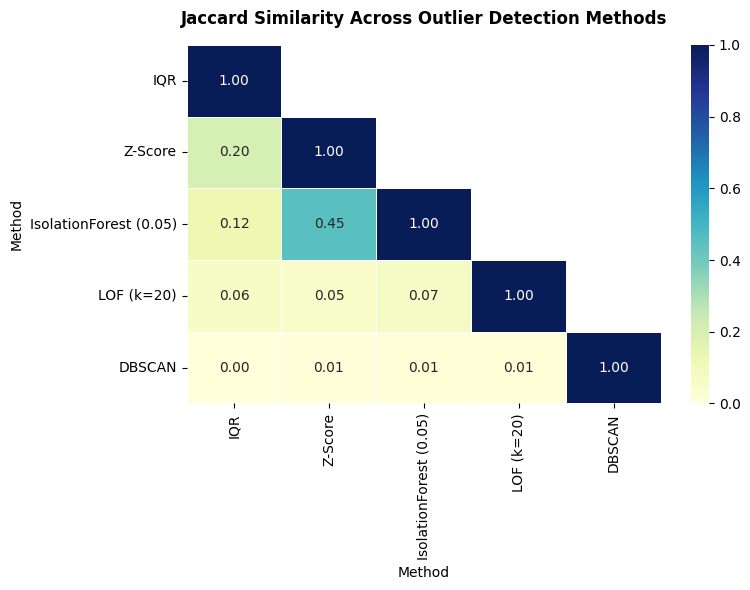

In [7]:
# Jaccard similarity function
def jaccard_similarity(set_a: set, set_b: set) -> float:
    """
    Compute Jaccard similarity between two sets.
    J(A, B) = |A ∩ B| / |A ∪ B|
    """
    if not set_a and not set_b:
        return 1.0  # both sets empty → identical
    return len(set_a.intersection(set_b)) / len(set_a.union(set_b))


# Select representative methods for comparison
methods = [
    'IQR',
    'Z-Score',
    'IsolationForest (0.05)',
    'LOF (k=20)',
    'DBSCAN'
]
n_methods = len(methods)
jaccard_matrix = np.zeros((n_methods, n_methods))

# Compute pairwise Jaccard similarity matrix
for i, method_i in enumerate(methods):
    for j, method_j in enumerate(methods):
        jaccard_matrix[i, j] = jaccard_similarity(
            outlier_indices[method_i],
            outlier_indices[method_j]
        )

df_jaccard = pd.DataFrame(
    jaccard_matrix,
    index=methods,
    columns=methods
)

mask = np.triu(np.ones_like(df_jaccard, dtype=bool), k=1)
# Visualization: Jaccard similarity heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_jaccard, mask=mask, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, linewidths=0.5)

plt.title(
    "Jaccard Similarity Across Outlier Detection Methods",
    fontweight='bold', pad=15
)
plt.xlabel("Method")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

In [8]:
# Consensus outlier detection
all_detected_indices = []
for method in methods:
    all_detected_indices.extend(outlier_indices[method])
outlier_counter = Counter(all_detected_indices)

# Majority voting threshold
threshold = 3
consensus_outliers = [
    idx for idx, count in outlier_counter.items()
    if count >= threshold
]

n_consensus = len(consensus_outliers)
consensus_rate = (n_consensus / len(X)) * 100
print("\tCONSENSUS OUTLIER DETECTION (MAJORITY VOTING)")
print(f"Selected methods: {len(methods)}")
print(f"Voting threshold: >= {threshold} methods")
print(f"Consensus outliers: {n_consensus:,}")
print(f"Consensus rate: {consensus_rate:.2f}%")

	CONSENSUS OUTLIER DETECTION (MAJORITY VOTING)
Selected methods: 5
Voting threshold: >= 3 methods
Consensus outliers: 1,440
Consensus rate: 4.42%


Việc quan sát biểu đồ Heatmap Jaccard Similarity và kết quả bỏ phiếu đa số cung cấp cho nhóm cơ sở toán học vững chắc để gạn lọc ngoại lai:

**1. Jaccard Heatmap:**
* *Z-Score và Isolation Forest (0.05) có độ đồng thuận cao nhất ($Jaccard = 0.45$):* Cả hai thuật toán này đều có xu hướng nhắm vào các "Global Outliers" – những điểm nằm xa nhất so với trung tâm dữ liệu. Sự nhất trí này khẳng định những người có `capital.gain` hoặc `age` cực cao chắc chắn sẽ bị cả hai mô hình này tóm gọn.
* **LOF ($Jaccard \le 0.07$):** LOF gần như không có sự giao thoa với IQR, Z-Score hay iForest. Điều này hoàn toàn khớp với cơ sở lý thuyết: LOF tìm kiếm *Local Outliers*. Nó phát hiện ra những cá nhân có thuộc tính "bất thường so với những người giống họ" (ví dụ: một người trẻ tuổi, học vấn thấp nhưng lại có giờ làm việc và tài sản biến động lạ thường), chứ không đơn thuần là xét theo điểm cực đại toàn cục.

**2. Consensus Outliers:**
* Bằng cách áp dụng luật bỏ phiếu nghiêm ngặt (được cảnh báo bởi $\ge 3$ thuật toán), nhóm đã lọc ra được *1.440 quan sát (chiếm 4.42%)* là ngoại lai chắc chắn.
* *Giá trị của Ensemble:* Thay vì tin tưởng mù quáng vào IQR (phá hủy 41% dữ liệu) hay Z-Score (bị nhiễu bởi phân phối không chuẩn), cơ chế đồng thuận đã ép các thuật toán phải "kiểm chứng chéo" lẫn nhau. Con số $4.42\%$ là một tỷ lệ cực kỳ an toàn, hợp lý và đại diện cho những trường hợp sai số/cực đoan thực sự trong tập dữ liệu dân số $32.000$ mẫu.

### **4.4. Distributional Impact via KS Test**

Nếu loại bỏ trực tiếp tập ngoại lai đồng thuận này, liệu chúng ta có làm thay đổi hoàn toàn bản chất phân phối của dữ liệu gốc hay không? Nhóm sử dụng *Two-Sample Kolmogorov-Smirnov Test* để so sánh phân phối của cột `age` (đại diện) trước và sau khi xóa.

* $H_0$: Phân phối trước và sau khi xóa ngoại lai là hoàn toàn giống nhau.
* $H_1$: Xóa ngoại lai làm thay đổi/biến dạng phân phối dữ liệu (P-value $< 0.05$).

In [9]:
feature = 'age'
dist_before = X[feature].values
dist_after = X.drop(index=X.index[consensus_outliers])[feature].values

# Perform Kolmogorov–Smirnov test
ks_statistic, p_value = stats.ks_2samp(dist_before, dist_after)

print("\tKOLMOGOROV–SMIRNOV TEST (DISTRIBUTION SHIFT ANALYSIS)")
print(f"Feature evaluated: {feature}")
print(f"Sample size (before): {len(dist_before):,}")
print(f"Sample size (after): {len(dist_after):,}")
print(f"KS statistic (D): {ks_statistic:.4f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
print("\nInterpretation:")
if p_value < alpha:
    print("Reject the null hypothesis (H0).")
else:
    print("Fail to reject the null hypothesis (H0).")

	KOLMOGOROV–SMIRNOV TEST (DISTRIBUTION SHIFT ANALYSIS)
Feature evaluated: age
Sample size (before): 32,561
Sample size (after): 31,121
KS statistic (D): 0.0087
P-value: 1.8029e-01

Interpretation:
Fail to reject the null hypothesis (H0).


**Kết quả thực nghiệm:**
Với P-value đạt $0.1802$ (lớn hơn mức ý nghĩa $\alpha = 0.05$), ta *chấp nhận giả thuyết $H_0$*. Việc loại bỏ 1.440 quan sát không tạo ra sự khác biệt có ý nghĩa thống kê đối với hàm phân phối tích lũy (CDF) của tập dữ liệu.


### **4.5. Treatment Strategy: Majority Voting & Statistical Validation**

Dựa trên kết quả thực nghiệm từ ma trận Jaccard và kiểm định Kolmogorov-Smirnov (KS), nhóm đưa ra các nhận định và quyết định cuối cùng trong giai đoạn tiền xử lý ngoại lai:

1. **Sự mâu thuẫn về bản chất thuật toán:** Các thuật toán định chuẩn toàn cục (Z-Score, IQR) có sự đồng thuận với nhau, nhưng rất lệch pha với các thuật toán dựa trên cấu trúc hình học không gian (LOF). Điều này chứng minh định lý cơ bản: *"Ngoại lai trong thống kê đơn biến chưa chắc đã là ngoại lai trong không gian đa chiều"*.
2. **Ensemble Success:** Việc KS Test trả về kết quả an toàn (P-value $> 0.05$) là minh chứng toán học cho cơ chế "bỏ phiếu đa số" ($\ge 3$ thuật toán). Nhờ cơ chế này, nhóm đã chỉ nhắm mục tiêu vào 4.42% dữ liệu thực sự là "rác" (noise) hoặc lỗi hệ thống (ví dụ: người 90 tuổi làm việc 99 giờ/tuần), bảo vệ thành công cấu trúc phân phối gốc của Cục điều tra dân số.
3. **Treatment Strategy:** Dựa trên KS Test, nhóm quyết định *DROP* 1.440 quan sát ngoại lai đồng thuận này ra khỏi tập huấn luyện.
   * Hành động này sẽ giúp làm sạch bề mặt hao phí, giúp các mô hình Machine Learning ở giai đoạn sau (đặc biệt là Logistic Regression và SVM) hội tụ nhanh hơn và không bị nhiễu trọng số.
   * Riêng đối với các ngoại lai dạng "tầng lớp siêu giàu" (chỉ kích hoạt Z-score ở cột `capital.gain` nhưng không bị LOF/DBSCAN bắt), chúng đã được giữ lại an toàn do không đủ 3 phiếu bầu. Để xử lý mức độ chênh lệch của nhóm người giàu này, ở **mục 5**, nhóm sẽ áp dụng *Robust Scaling* hoặc *Quantile Transformer*.

In [10]:
df_adult_clean = df_adult.drop(index=consensus_outliers).reset_index(drop=True)
print(f"Dataset size after cleaning outliers: {df_adult_clean.shape}")

Dataset size after cleaning outliers: (31121, 15)


## **5. Data Scaling & Homoscedasticity**

### **5.1. Theoretical Foundation & Mathematical Formulas**

Để lựa chọn chiến lược chuẩn hóa phù hợp nhất cho từng đặc trưng, nhóm áp dụng và đối chiếu 4 phương pháp luận dựa trên cấu trúc phân phối của dữ liệu.

#### 1. Min-Max Scaling (Normalization)

* **Lý thuyết:** Phép biến đổi tuyến tính chiếu dữ liệu vào một khoảng cố định (thường là $[0, 1]$). Nó bảo toàn nguyên vẹn khoảng cách tương đối giữa các điểm dữ liệu. Ưu điểm lớn nhất là không làm thay đổi hình dáng phân phối gốc. Tuy nhiên, nó cực kỳ nhạy cảm với ngoại lai; một ngoại lai ở biên có thể nén toàn bộ inlier vào một không gian cực nhỏ, triệt tiêu phương sai của đặc trưng.
* **Toán học:** Chuyển đổi đặc trưng $X$ về khoảng tiêu chuẩn $[0, 1]$:
  $$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

#### 2. Z-score Standardization

* **Lý thuyết:** Chuẩn hóa dữ liệu xoay quanh giá trị trung bình là 0 và phương sai đơn vị là 1. Giả định dữ liệu tiệm cận phân phối Gaussian. Dữ liệu chuẩn hóa không bị giới hạn biên độ, phù hợp cho các thuật toán như SVM hay Logistic Regression. Dù chống chịu ngoại lai tốt hơn Min-Max, ngoại lai cực đoan vẫn có thể làm phình to độ lệch chuẩn $\sigma$ và kéo lệch tâm $\mu$.
* **Toán học:**
  $$Z = \frac{X - \mu}{\sigma}$$

#### 3. Robust Scaling

* **Lý thuyết:** Khi dữ liệu bị ô nhiễm bởi các phân phối đuôi dày (heavy-tailed) hoặc ngoại lai cực đoan, Robust Scaling sử dụng các công cụ ước lượng thống kê có "breakdown point" cao. Thuật toán dịch tâm bằng trung vị (breakdown point $\approx 50\%$) và co giãn bằng khoảng tứ phân vị IQR (điểm gãy $\approx 25\%$). Nhờ tập trung vào 50% dữ liệu vùng trung tâm, nó loại bỏ hoàn toàn sự nhiễu loạn từ hai phần đuôi ngoại lai.
* **Toán học:**
  $$X_{scaled} = \frac{X - Median(X)}{Q_3(X) - Q_1(X)}$$

#### 4. Quantile Transform (Non-Parametric Mapping)

* **Lý thuyết:** Đối với dữ liệu đa đỉnh hoặc vi phạm nghiêm trọng tính chuẩn/tuyến tính, Quantile Transform ánh xạ phi tuyến phân phối thực nghiệm của đặc trưng sang một phân phối đích.
  * **Uniform Output:** Dựa trên hàm phân phối tích lũy thực nghiệm (ECDF), trải đều các giá trị xuất hiện thường xuyên và thu hẹp khoảng cách của các ngoại lai.
  * **Normal Output:** Ánh xạ dữ liệu sang phân phối đều qua ECDF, sau đó áp dụng hàm Probit ($\Phi^{-1}$ - nghịch đảo của CDF chuẩn) để "ép" dữ liệu thành hình chuông hoàn hảo.
* **Toán học (Normal Output):**
  $$Y = \Phi^{-1}(F(X))$$

#### 5. Assessing Homoscedasticity: Levene’s Test

* **Lý thuyết:** Đồng nhất phương sai (Homoscedasticity) ngụ ý rằng phương sai của sai số không đổi trên mọi cấp độ của biến độc lập. Việc vi phạm (Heteroscedasticity) sẽ làm chệch các ước lượng thống kê. Nhóm sử dụng Levene's Test (phiên bản Brown-Forsythe dùng trung vị, rất mạnh mẽ trên dữ liệu không chuẩn) để kiểm tra sự đồng nhất phương sai của các biến số học giữa 2 nhóm giai cấp thu nhập (`<=50K` và `>50K`).
* **Toán học:**
  * Tính độ lệch tuyệt đối so với tâm nhóm $C_i$:
  $$Z_{ij} = |Y_{ij} - C_i|$$

  * Tính thống kê $W$ (Tỷ lệ phương sai giữa các nhóm trên phương sai nội bộ nhóm):
  $$
  W = \frac{N - k}{k - 1} \cdot
  \frac{\sum_{i=1}^{k} N_i \left(\bar{Z}_{i\cdot} - \bar{Z}_{\cdot\cdot}\right)^2}
  {\sum_{i=1}^{k} \sum_{j=1}^{N_i} \left(Z_{ij} - \bar{Z}_{i\cdot}\right)^2}
  $$
  
  * *Hệ quả:* Trị số $W$ tuân theo phân phối $F$. $P-value$ $< \alpha$ (thường là $0.05$) biểu thị bác bỏ $H_0$, xác nhận sự tồn tại của phương sai không đồng nhất.

### **5.2. Scaling Implementations**

Nhóm khởi tạo và áp dụng đồng loạt 5 chiến lược chuẩn hóa (bao gồm cả phân phối đích Uniform và Normal của Quantile Transformer) lên *toàn bộ 6 biến số học*. Quá trình này tạo ra các không gian đặc trưng song song để chuẩn bị cho quá trình đánh giá định lượng và trực quan.

In [11]:
# Define numerical features and target variable
num_cols = [
    'age', 'fnlwgt', 'education.num',
    'capital.gain', 'capital.loss', 'hours.per.week'
]
X_num = df_adult_clean[num_cols].copy()
y = df_adult_clean['income'].copy()

# Initialize scaling methods
scalers = {
    'Original': None,
    'Min-Max Scaling': MinMaxScaler(),
    'Standard Scaling (Z-score)': StandardScaler(),
    'Robust Scaling (IQR)': RobustScaler(),
    'Quantile (Uniform)': QuantileTransformer(
        output_distribution='uniform',
        random_state=42
    ),
    'Quantile (Normal)': QuantileTransformer(
        output_distribution='normal',
        random_state=42
    )
}

# Apply transformations
scaled_datasets = {}
for name, scaler in scalers.items():
    if scaler is None:
        scaled_datasets[name] = X_num.copy()
    else:
        transformed = scaler.fit_transform(X_num)
        scaled_datasets[name] = pd.DataFrame(
            transformed,
            columns=num_cols,
            index=X_num.index
        )

print("\tFEATURE SCALING COMPLETED")
print(f"Number of samples: {X_num.shape[0]:,}")
print(f"Number of features: {X_num.shape[1]}")
print(f"Scaling methods applied: {len(scalers)}\n")
print("Available transformed datasets:")
for name in scaled_datasets.keys():
    print(f" - {name}")

	FEATURE SCALING COMPLETED
Number of samples: 31,121
Number of features: 6
Scaling methods applied: 6

Available transformed datasets:
 - Original
 - Min-Max Scaling
 - Standard Scaling (Z-score)
 - Robust Scaling (IQR)
 - Quantile (Uniform)
 - Quantile (Normal)


In [12]:
# Example preview
print("\nPreview: Standard Scaling (first 5 rows)")
display(scaled_datasets['Standard Scaling (Z-score)'].head())


Preview: Standard Scaling (first 5 rows)


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
0,0.205869,-0.179660,-0.417302,-0.236924,9.155375,-0.017807
1,-0.317500,-0.077409,-0.019250,-0.236924,9.155375,-0.017807
2,0.504938,0.179612,0.776855,-0.236924,8.733265,-0.017807
3,-0.616568,-0.390882,-0.417302,-0.236924,8.635199,-0.017807
4,-0.317500,0.109078,-0.019250,-0.236924,8.635199,-0.017807


### **5.3 Homoscedasticity Assessment**

Nhóm áp dụng *Levene's Test (Brown-Forsythe variant, sử dụng Median)* quét qua toàn bộ 6 thuộc tính định lượng.
* $H_0$: Phương sai của biến số giữa hai nhóm thu nhập (`<=50K` và `>50K`) là bằng nhau (Homoscedasticity).
* $H_1$: Có sự khác biệt ý nghĩa về phương sai (Heteroscedasticity).

Mục tiêu là kiểm tra xem phép chuẩn hóa nào giúp duy trì, hoặc ép cưỡng bức được sự đồng nhất phương sai (đạt P-value $> 0.05$).

In [13]:
levene_results = []

# Perform Levene's test for each feature and scaling method
for feature in num_cols:
    for method_name, df_scaled in scaled_datasets.items():

        # Split data into two groups based on target label
        group_low = df_scaled.loc[y == '<=50K', feature].dropna()
        group_high = df_scaled.loc[y == '>50K', feature].dropna()

        # Apply Levene's test (median-centered for robustness against outliers)
        stat, p_value = stats.levene(group_low, group_high, center='median')

        # Store results
        levene_results.append({
            'Feature': feature,
            'Scaling Method': method_name,
            'P-value': p_value
        })

# Convert results to pivot table
df_levene = (
    pd.DataFrame(levene_results)
    .pivot(index='Feature', columns='Scaling Method', values='P-value')
    .sort_index()
)

print("\tLEVENE'S TEST RESULTS (HOMOGENEITY OF VARIANCE)")
print("Hypothesis:")
print(" - H0: Equal variances across income groups")
print(" - H1: Unequal variances\n")

display(
    df_levene.style
    .format("{:.4f}")
    .highlight_between(
        left=0,
        right=0.05,
        color='#923232'
    )
)

	LEVENE'S TEST RESULTS (HOMOGENEITY OF VARIANCE)
Hypothesis:
 - H0: Equal variances across income groups
 - H1: Unequal variances



Scaling Method,Min-Max Scaling,Original,Quantile (Normal),Quantile (Uniform),Robust Scaling (IQR),Standard Scaling (Z-score)
Feature,,,,,,
age,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
capital.gain,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
capital.loss,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
education.num,0.0000,0.0000,0.0000,0.0009,0.0000,0.0000
fnlwgt,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
hours.per.week,0.8298,0.8298,0.0000,0.0000,0.8298,0.8298


In [14]:
summary = (df_levene >= 0.05).sum().sort_values(ascending=False)
print("\nNumber of features satisfying homoscedasticity (p >= 0.05):")
print(summary)


Number of features satisfying homoscedasticity (p >= 0.05):
Scaling Method
Min-Max Scaling               1
Original                      1
Standard Scaling (Z-score)    1
Robust Scaling (IQR)          1
Quantile (Uniform)            0
Quantile (Normal)             0
dtype: int64


Dựa trên bảng kết quả kiểm định Levene, nhóm rút ra 3 luận điểm quan trọng về cấu trúc phương sai của dữ liệu:

**1. Inherent Heteroscedasticity:**
Đối với 5/6 biến số học (`age`, `capital.gain`, `capital.loss`, `education.num`, `fnlwgt`), chỉ số p-value đều bằng 0.0000 (nhỏ hơn rất nhiều mức ý nghĩa 0.05) trên mọi phương pháp chuẩn hóa. Ta *bác bỏ giả thuyết H0*. Điều này phản ánh một thực tế xã hội: Phương sai của hai tầng lớp thu nhập là hoàn toàn khác biệt (ví dụ: nhóm giàu có sự biến thiên cực lớn về tài sản đầu tư, trong khi nhóm nghèo gần như bằng 0). Các phép chuẩn hóa tuyến tính (Min-Max, Z-Score) chỉ dịch chuyển hệ trục tọa độ, hoàn toàn không thể làm thay đổi bản chất bất đồng nhất này.

**2. `hours.per.week`:**
Đây là thuộc tính duy nhất vượt qua kiểm định (p-value = 0.8298 > 0.05) và *chấp nhận H0* ở dữ liệu gốc. Con số này cho thấy: Sự phân tán về thời gian làm việc của cả người giàu lẫn người nghèo là tương đương nhau (dao động quanh mốc tiêu chuẩn 40 giờ/tuần). Các phép chuẩn hóa tuyến tính và Robust Scaling đã bảo toàn thành công cấu trúc phương sai ổn định này.

**3. Quantile Distortion:**
Một điểm cực kỳ đáng lưu tâm là *Quantile Transform* (cả Uniform và Normal) đã phá vỡ hoàn toàn tính đồng nhất phương sai của biến `hours.per.week` (kéo p-value từ 0.8298 tụt xuống 0.0000). Phép biến đổi phi tuyến này ép cưỡng bức dữ liệu theo thứ hạng, vô tình làm bóp méo cấu trúc phân bố tự nhiên và tạo ra sự chênh lệch phương sai giả giữa hai nhóm.

**Strategic Conclusion:** Thay vì cố gắng đồng nhất phương sai, nhóm sẽ chọn các bộ chuẩn hóa giúp tối ưu bề mặt hao phí (Loss Landscape) cho mô hình Học máy: *kết hợp Min-Max (cho các biến có phương sai ổn định như `hours.per.week`) và Robust Scaling (để kiềm chế các biến lệch cực đoan như `capital.gain`).*

### **5.4 Visualizing Distributional Impact**

Để minh họa trực quan sự thay đổi trong cấu trúc dữ liệu dưới tác động của các bộ chuẩn hóa, nhóm sử dụng biểu đồ Violin Plot trên thuộc tính `capital.gain`. Biểu đồ này giúp quan sát đồng thời cả các chỉ số tứ phân vị (giống Boxplot) và hình dáng hàm mật độ xác suất KDE (Kernel Density Estimation).

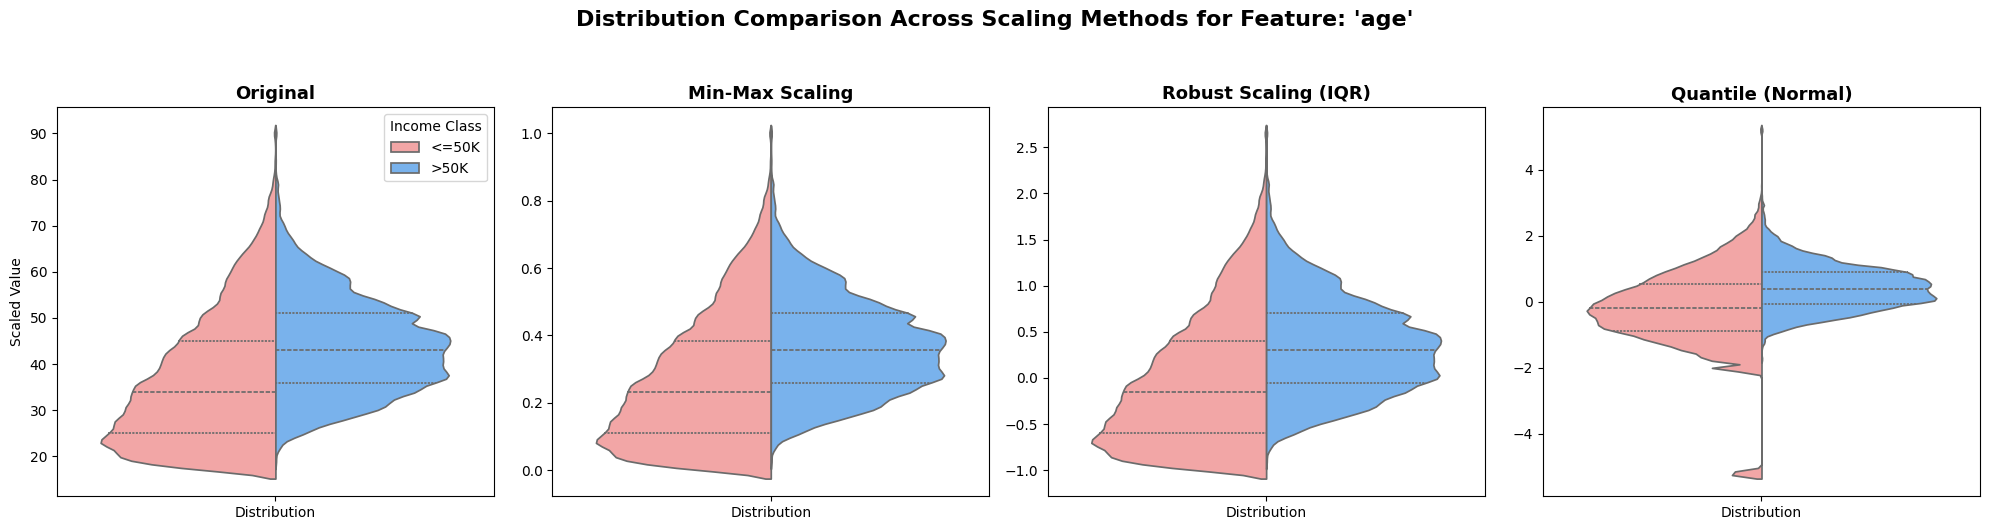

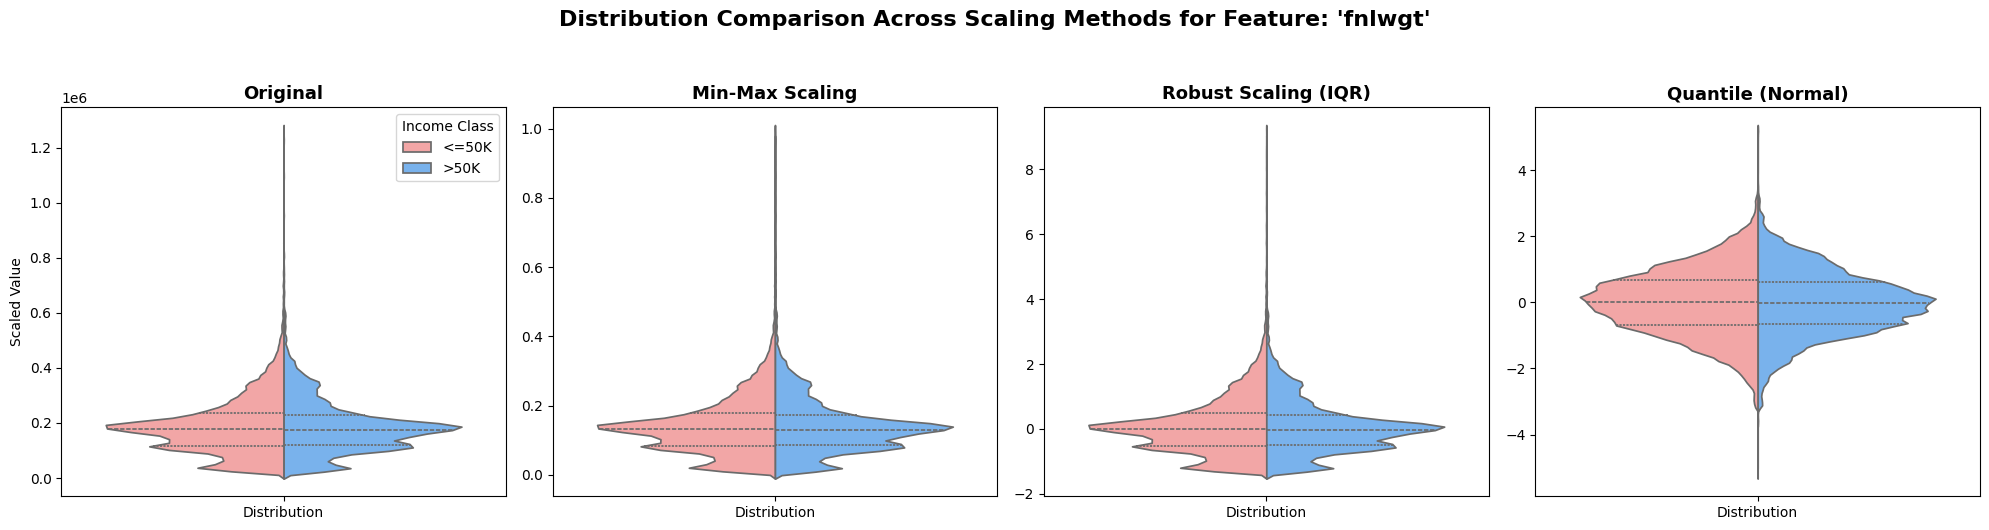

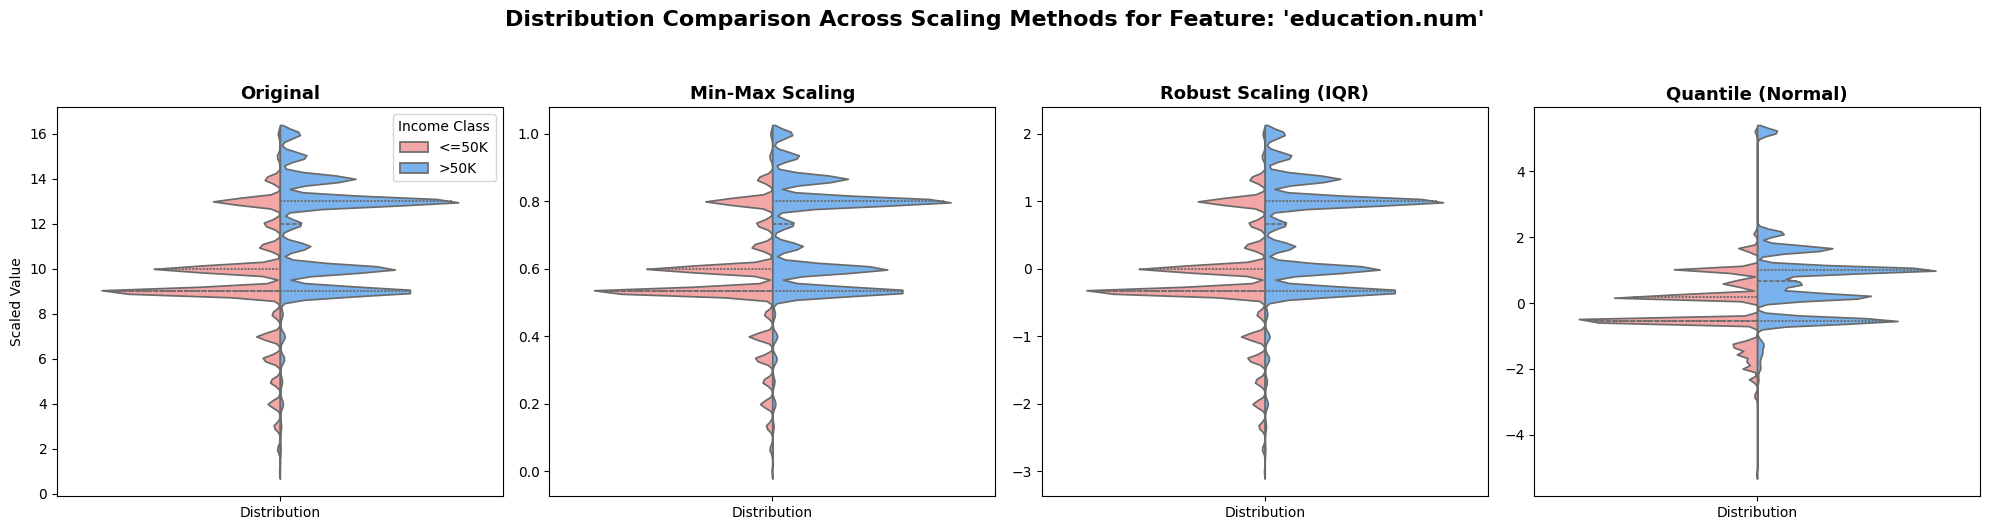

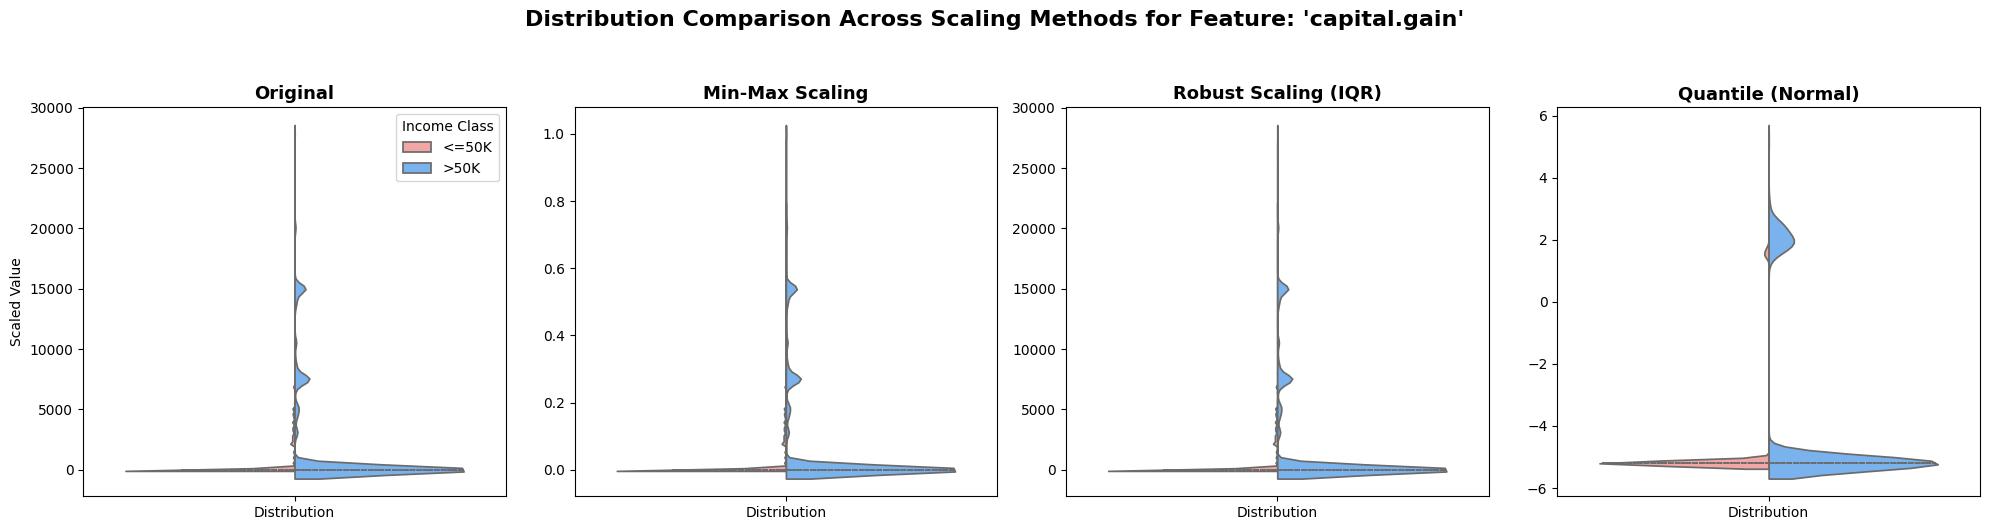

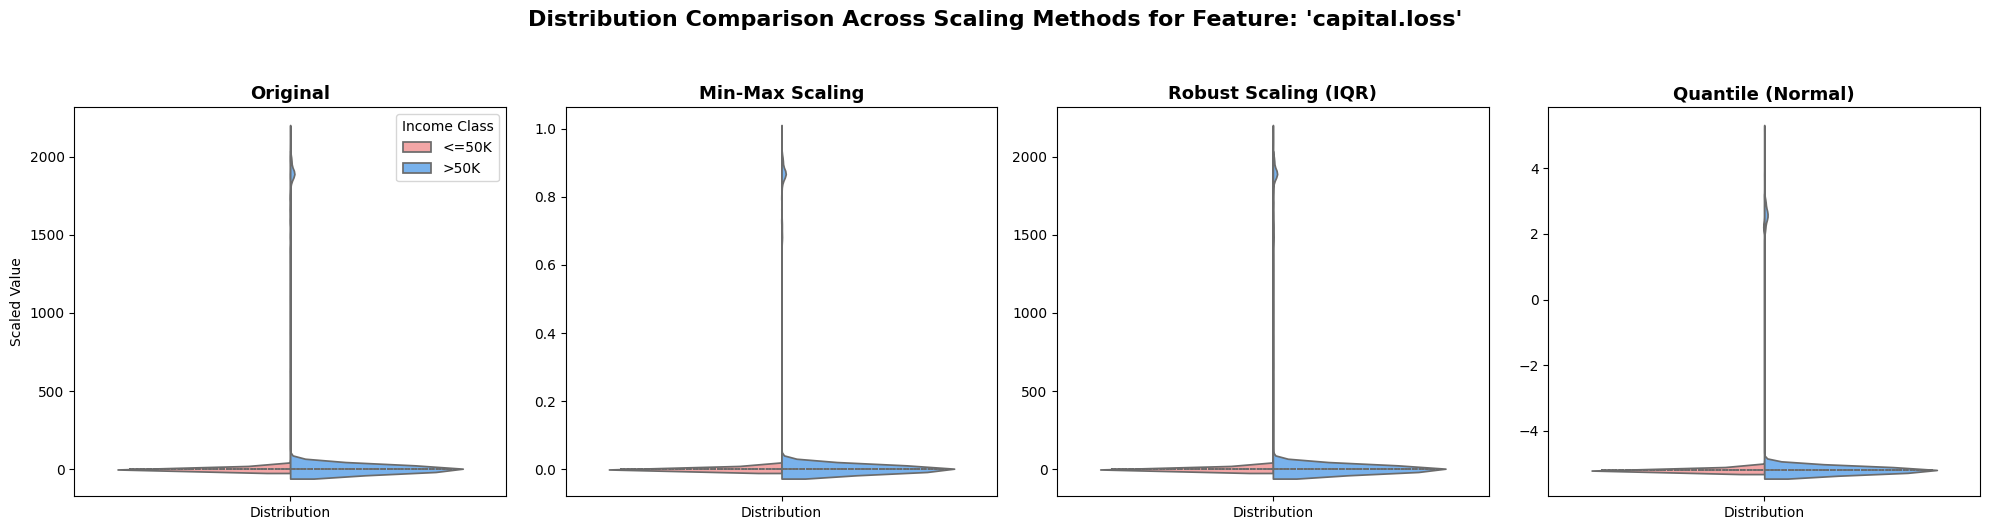

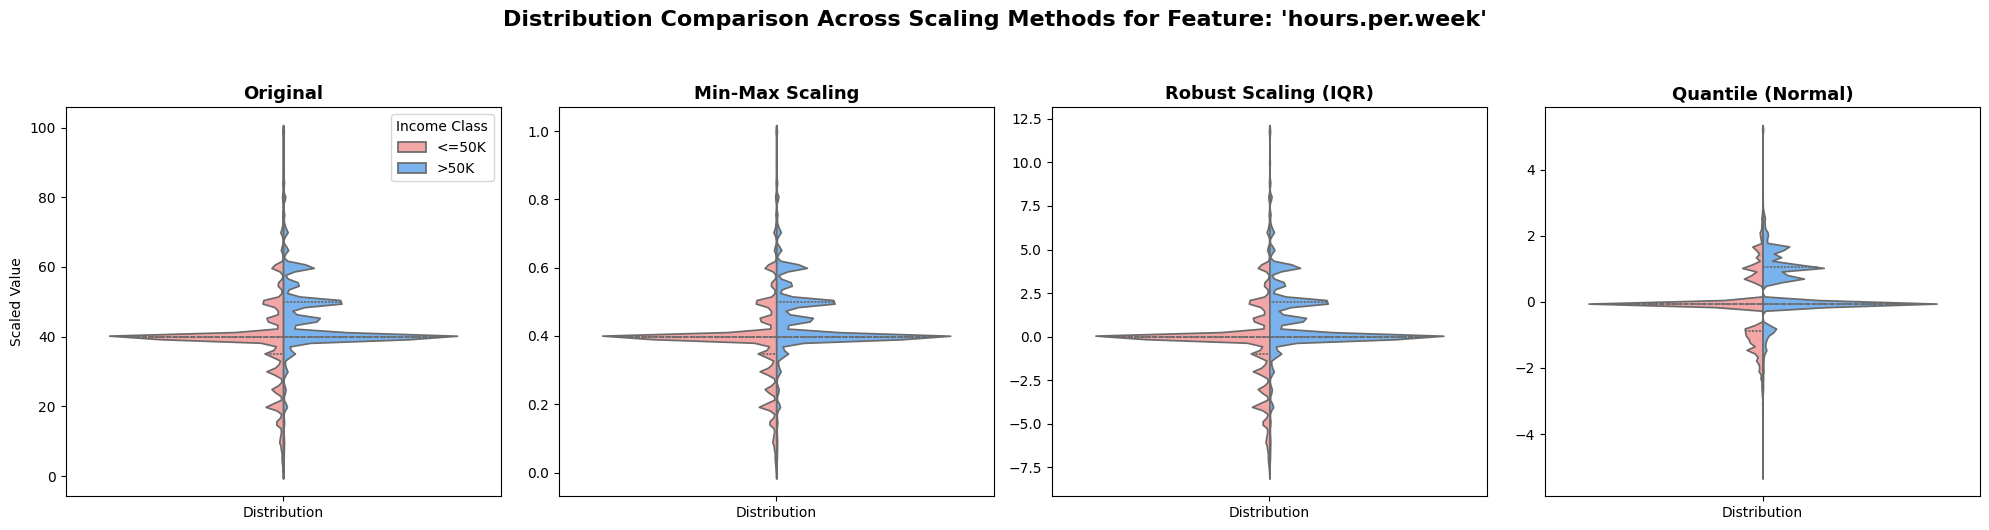

In [15]:
# Select representative scaling methods
methods_to_plot = [
    'Original',
    'Min-Max Scaling',
    'Robust Scaling (IQR)',
    'Quantile (Normal)'
]

# Visualization loop for all numerical features
for feature in num_cols:
    # Create subplot grid (one column per scaling method)
    fig, axes = plt.subplots(
        1,
        len(methods_to_plot),
        figsize=(20, 5),
        sharey=False
    )
    for i, method in enumerate(methods_to_plot):

        # Extract scaled data
        data_scaled = scaled_datasets[method][feature].dropna()
        y_aligned = y.loc[data_scaled.index]

        # Prepare plotting DataFrame
        df_plot = pd.DataFrame({
            'Scaled Value': data_scaled.values,
            'Income Class': y_aligned.values,
            'Group': 'Distribution'
        })

        # Plot split violin
        sns.violinplot(
            data=df_plot,
            x='Group',
            y='Scaled Value',
            hue='Income Class',
            split=True,
            inner='quartile',
            density_norm='area',
            bw_adjust=0.5,
            palette=['#FF9999', '#66B2FF'],
            ax=axes[i],
            legend=(i == 0)
        )
        axes[i].set_title(
            f"{method}",
            fontsize=13,
            fontweight='bold'
        )
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Scaled Value" if i == 0 else "")
    plt.suptitle(
        f"Distribution Comparison Across Scaling Methods for Feature: '{feature}'",
        fontsize=16,
        fontweight='bold',
        y=1.05
    )
    plt.tight_layout()
    plt.show()

### **5.6 Critical Review and Final Scaling Strategy**

Sau khi đối chiếu kết quả kiểm định Levene's Test và quan sát sự biến thiên hình thái qua 6 biểu đồ Split Violin, nhóm đánh giá tác động của các bộ chuẩn hóa lên từng nhóm đặc trưng như sau:

**1. Nhóm biến có ranh giới xã hội rời rạc (`hours.per.week`, `education.num`):**
* **Hiện tượng:** Biểu đồ Original cho thấy các "đỉnh nhọn" rất rõ nét tại các giá trị thường gặp trong xã hội, ví dụ: 40 giờ làm việc mỗi tuần hoặc 13 năm học (tương đương bằng cử nhân). Điều này cho thấy dữ liệu tập trung nhiều ở những mốc thời gian này.
* **Quantile (Normal):** Phép biến đổi Quantile (thường được gọi là biến đổi "Normal") là một phép biến đổi phi tuyến. Nó đã làm "phẳng" hoàn toàn các đỉnh nhọn này, biến biểu đồ thành một hình chuông (phân phối Gaussian). Về mặt toán học, nó tạo ra phân phối chuẩn; nhưng về mặt nghiệp vụ, nó loại bỏ hoàn toàn thông tin xã hội học quan trọng có trong dữ liệu gốc. Các mốc như 40 giờ/tuần hoặc 13 năm học không còn được thể hiện rõ ràng nữa. Hơn nữa, như Levene's Test đã chỉ ra, nó còn phá vỡ tính đồng nhất phương sai của biến `hours.per.week`. Điều này có nghĩa là phương sai (mức độ phân tán) của dữ liệu trong các nhóm khác nhau trở nên không đồng đều, ảnh hưởng đến một số phân tích thống kê.


**2. Nhóm biến phân phối lệch cực đoan (`capital.gain`, `capital.loss`):**
* **Hiện tượng:** Đây là các biến Zero-inflated (phần lớn dân số có giá trị bằng 0).
* **Min-Max:** Khi áp dụng Min-Max scaling, biểu đồ Violin cho thấy 99% dữ liệu bị "nén" thành một đường thẳng mỏng ở giá trị 0. Điều này xảy ra vì một số ít cá nhân có giá trị rất lớn (siêu giàu) làm cho phạm vi giá trị rất rộng. Kết quả là, phương sai (variance) của phần lớn dữ liệu bị triệt tiêu, làm giảm hiệu quả học máy.
* **Robust Scaler:** Thuật toán Robust Scaler giữ giá trị 0 ở vị trí trung tâm (do giá trị trung vị (Median) bằng 0). Nó cũng giúp giảm ảnh hưởng của các giá trị ngoại lai (outliers) mà không làm mất đi cấu trúc đuôi dài (heavy-tail) của phân phối.

**3. Nhóm biến phân phối tự nhiên (`age`, `fnlwgt`):**
* Với biến `age` (tuổi), các biểu đồ Original (gốc), Min-Max (tỉ lệ về [0,1]), và Robust (loại bỏ outlier) cho thấy sự khác biệt rõ ràng giữa các thế hệ: Nhóm có thu nhập $\le50K$ (màu đỏ) tập trung nhiều ở độ tuổi thanh niên 20-30, trong khi nhóm có thu nhập $>50K$ (màu xanh) đạt đỉnh muộn hơn, ở độ tuổi trung niên 40-50. Cả phương pháp Min-Max và Robust đều giữ lại rất tốt câu chuyện "tích lũy tài sản theo thời gian" này.

**SCALING STRATEGY: HYBRID SCALING**

1. **Sử dụng MinMaxScaler:** Cho các biến mang ý nghĩa mốc thời gian/giáo dục (`age`, `education.num`, `hours.per.week`). Việc này giúp dưa dữ liệu về khoảng [0, 1] để tối ưu hóa thuật toán, đồng thời vẫn giữ nguyên các điểm đặc biệt (ví dụ: mốc 40 giờ làm việc) và khoảng cách tương đối giữa các dữ liệu.
2. **Sử dụng RobustScaler:** Bắt buộc áp dụng cho các biến tài chính nhạy cảm với ngoại lai (`capital.gain`, `capital.loss`) và `fnlwgt`. Sử dụng khoảng tứ phân vị (IQR) giúp giảm ảnh hưởng của các giá trị ngoại lai, đặc biệt là của những người có thu nhập rất cao, mà không làm sai lệch thực tế là phần lớn dân số không có thu nhập từ đầu tư.
3. **Loại bỏ QuantileTransformer:** Mặc dù tạo ra phân phối chuẩn đẹp, nhưng việc làm méo cấu trúc dữ liệu rời rạc và làm sai lệch ý nghĩa xã hội học khiến nó không phù hợp với bài toán phân loại nhân khẩu học Adult Census.

In [16]:
minmax_cols = ['age', 'education.num', 'hours.per.week']
robust_cols = ['capital.gain', 'capital.loss', 'fnlwgt']
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
df_adult_clean[minmax_cols] = minmax_scaler.fit_transform(df_adult_clean[minmax_cols])
df_adult_clean[robust_cols] = robust_scaler.fit_transform(df_adult_clean[robust_cols])


print("\tDESCRIBED STATISTICS AFTER STANDARDIZATION")
display(df_adult_clean[minmax_cols + robust_cols].describe().round(3))

	DESCRIBED STATISTICS AFTER STANDARDIZATION


,age,education.num,hours.per.week,capital.gain,capital.loss,fnlwgt
count,31121.000,31121.000,31121.000,31121.000,31121.000,31121.000
mean,0.291,0.603,0.400,541.027,31.737,0.088
std,0.183,0.167,0.120,2283.587,234.539,0.871
min,0.000,0.000,0.000,0.000,0.000,-1.408
25%,0.137,0.533,0.398,0.000,0.000,-0.511
50%,0.274,0.600,0.398,0.000,0.000,0.000
75%,0.411,0.733,0.449,0.000,0.000,0.489
max,1.000,1.000,1.000,27828.000,2179.000,9.241


## **6. Advanced Categorical Encoding**

**Mục tiêu:** Chuyển đổi dữ liệu chuỗi (String/Categories) thành biểu diễn không gian số học mà không làm bùng nổ số chiều, đồng thời tránh hiện tượng học vẹt nhãn (Target Leakage).

### **6.1 Theoretical Foundation & Mathematical Formulas**

Trước khi áp dụng các kỹ thuật nâng cao, ta cần hiểu rõ giới hạn của các phương pháp cơ sở.

**One-Hot Encoding (OHE)** chuyển mỗi giá trị của biến thành một cột riêng, mỗi cột chỉ chứa 0 hoặc 1. Độ phức tạp của việc này là $O(k)$, với $k$ là số lượng giá trị duy nhất của biến đó. Nếu biến có quá nhiều giá trị duy nhất (high-cardinality), OHE sẽ tạo ra một ma trận rất lớn và toàn số 0 (ma trận thưa), dẫn đến các vấn đề như "curse of dimensionality" và đa cộng tuyến hoàn hảo.

**Ordinal Encoding** ngược lại, thay thế mỗi giá trị bằng một số nguyên (ví dụ: $1, 2, \dots, k$). Tuy nhiên, phương pháp này lại tạo ra những "khoảng cách giả" giữa các giá trị, đặc biệt là khi dữ liệu không có thứ tự tự nhiên (nominal data).

Để khắc phục, nhóm áp dụng các mô hình mã hóa nén không gian và sử dụng thông tin mục tiêu:

#### 1. Target Encoding (Mean Encoding) với Cross-Validation

* **Lý thuyết:** Thay thế hạng mục bằng giá trị trung bình của biến mục tiêu (Target) tương ứng với hạng mục đó.
* **Toán học:** Giá trị mã hóa $\hat{x}_c$ cho hạng mục $c$:
  $$\hat{x}_c = \frac{1}{n_c} \sum_{i \in L_c} y_i$$
* **Chống Target Leakage:** Nếu chỉ dùng công thức trên, mô hình sẽ "học vẹt" nhãn của tập Train. Để ngăn chặn, ta sử dụng *Bayesian Smoothing* (Kéo giá trị của các hạng mục hiếm về trung bình toàn cục) kết hợp với *K-Fold Cross-Validation* (Giá trị mã hóa của Fold này được tính từ $K-1$ Folds còn lại, đảm bảo dữ liệu không tự "nhìn thấy" nhãn của chính nó).
  * *Hệ số làm mượt:* $S_c = \lambda(n_c) \bar{y}_c + (1 - \lambda(n_c)) \bar{y}_{global}$

#### 2. Binary Encoding

* **Lý thuyết:** Kỹ thuật nén bộ nhớ cực kỳ hiệu quả cho biến High-Cardinality. Nó kết hợp ánh xạ số nguyên và chuyển đổi bit nhị phân.
* **Toán học:** Giảm không gian đặc trưng từ $k$ chiều xuống còn $\lceil \log_2(k) \rceil$ chiều. Ví dụ: Biến có 100 hạng mục thay vì tốn 100 cột OHE, nay chỉ tốn $\lceil \log_2(100) \rceil = 7$ cột nhị phân.

#### 3. Frequency Encoding

* **Lý thuyết:** Thay thế tên hạng mục bằng tần suất xuất hiện của nó. Giả định rằng mức độ phổ biến của một hạng mục mang tín hiệu dự đoán. Hoàn toàn miễn nhiễm với Target Leakage.
* **Toán học:** $P(x) = \frac{count(x)}{N}$
* **Hạn chế (Collision):** Nếu hai hạng mục xuất hiện cùng số lần, chúng sẽ nhận cùng một giá trị toán học, làm mất đi sự phân biệt.

#### 4. Kỹ thuật đánh giá: Variance Inflation Factor (VIF)

* **Lý thuyết:** Biến đổi phân loại dễ sinh ra đa cộng tuyến (Multicollinearity). VIF đo lường mức độ phình to của phương sai hệ số hồi quy do sự phụ thuộc tuyến tính giữa các biến.
* **Toán học:** Cho biến $X_i$, hồi quy nó theo các biến còn lại để lấy $R_i^2$:
  $$VIF_i = \frac{1}{1 - R_i^2}$$
* **Đánh giá:** VIF $= 1$ (Hoàn toàn độc lập). VIF $> 5$ hoặc $10$ cảnh báo đa cộng tuyến nghiêm trọng cần phải loại bỏ đặc trưng.

### **6.2 Base & High-Cardinality Encodings Implementation**

Dựa trên số lượng hạng mục (Cardinality) và tính chất dữ liệu, nhóm phân chia chiến lược như sau:

1. **Base Encoding:**
    * **Ordinal Encoding:** Áp dụng cho biến có tính thứ bậc rõ ràng như `education`.
    * **One-Hot Encoding (OHE):** Áp dụng cho biến định danh ít hạng mục (`sex`, `race`, `relationship`, `marital.status`, `workclass`).
2. **High-Cardinality Encoding (đặc biệt cho biến $>20$ giá trị như `native.country` và phức tạp như `occupation`):**
    * **Target Encoding:** Sử dụng `TargetEncoder` từ Scikit-learn (hỗ trợ nội bộ K-Fold CV).
    * **Binary Encoding:** Nhóm tự định nghĩa hàm mã hóa bằng phép biến đổi chuỗi nhị phân tuyến tính $O(N)$ bằng `pandas`.
    * **Frequency Encoding:** Khai thác tỷ lệ phân phối từ hàm `value_counts`.

In [17]:
# Target Variable Processing
# Extract target variable and convert to binary format
y_raw = df_adult_clean['income']
y = y_raw.str.strip().map({'<=50K': 0, '>50K': 1})

# Identify Categorical Features
cat_cols = df_adult_clean.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('income')

# Define encoding strategies
ordinal_cols = ['education']
ohe_cols = ['sex', 'race', 'relationship', 'marital.status', 'workclass']
high_card_cols = ['native.country', 'occupation']

# Ordinal Encoding
ordinal_encoder = OrdinalEncoder()
df_ordinal = pd.DataFrame(
    ordinal_encoder.fit_transform(df_adult_clean[ordinal_cols]),
    columns=[f"{col}_ordinal" for col in ordinal_cols],
    index=df_adult_clean.index
)

# One-Hot Encoding
df_ohe = pd.get_dummies(
    df_adult_clean[ohe_cols],
    drop_first=True,
    dtype=int
)

# Combine base features
df_base = pd.concat([df_ordinal, df_ohe], axis=1)

# Initialize feature spaces
df_target_space = df_base.copy()
df_binary_space = df_base.copy()
df_frequency_space = df_base.copy()

# Target Encoding
target_encoder = TargetEncoder(
    cv=5,
    smooth='auto',
    random_state=42
)
encoded_target = target_encoder.fit_transform(
    df_adult_clean[high_card_cols],
    y
)
df_target_encoded = pd.DataFrame(
    encoded_target,
    columns=[f"{col}_target" for col in high_card_cols],
    index=df_adult_clean.index
)
df_target_space = pd.concat([df_target_space, df_target_encoded], axis=1)

# Binary Encoding
def binary_encode(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """
    Convert categorical variables into binary representation.
    Each category is mapped to an integer and then encoded as binary digits.
    """
    df_out = pd.DataFrame(index=df.index)
    for col in columns:
        cat_codes = df[col].astype('category').cat.codes
        max_val = cat_codes.max()
        num_bits = int(np.ceil(np.log2(max_val + 1))) if max_val > 0 else 1
        binary_format = f'0{num_bits}b'
        binary_strings = cat_codes.apply(
            lambda x: format(x, binary_format) if x >= 0 else format(0, binary_format)
        )
        for i in range(num_bits):
            df_out[f"{col}_bin_{i}"] = binary_strings.str[i].astype(int)
    return df_out
df_binary_encoded = binary_encode(df_adult_clean, high_card_cols)
df_binary_space = pd.concat([df_binary_space, df_binary_encoded], axis=1)

# Frequency Encoding
df_frequency_encoded = pd.DataFrame(index=df_adult_clean.index)
for col in high_card_cols:
    freq_map = df_adult_clean[col].value_counts(normalize=True)
    df_frequency_encoded[f"{col}_freq"] = df_adult_clean[col].map(freq_map)
df_frequency_space = pd.concat([df_frequency_space, df_frequency_encoded], axis=1)


print("\tSUMMARY")
print(f"Base Feature Space Shape: {df_base.shape}")
print(f"Target Encoding Feature Space: {df_target_space.shape}")
print(f"Binary Encoding Feature Space: {df_binary_space.shape}")
print(f"Frequency Encoding Feature Space: {df_frequency_space.shape}")

	SUMMARY
Base Feature Space Shape: (31121, 24)
Target Encoding Feature Space: (31121, 26)
Binary Encoding Feature Space: (31121, 34)
Frequency Encoding Feature Space: (31121, 26)


In [18]:
# Target Encoding Preview
print("\tTARGET ENCODING PREVIEW (First 5 Rows)")
target_cols_preview = [col for col in df_target_space.columns if '_target' in col]
display(df_target_space[target_cols_preview].head())

# Binary Encoding Preview
print("\tBINARY ENCODING PREVIEW (native.country)")
binary_cols_preview = [col for col in df_binary_space.columns if 'native.country_bin' in col]
display(df_binary_space[binary_cols_preview].head())

# Frequency Encoding Preview
print("\tFREQUENCY ENCODING PREVIEW")
freq_cols_preview = [col for col in df_frequency_space.columns if '_freq' in col]
display(df_frequency_space[freq_cols_preview].head())

	TARGET ENCODING PREVIEW (First 5 Rows)


,native.country_target,occupation_target
0,0.230796,0.056835
1,0.231049,0.181120
2,0.300709,0.133218
3,0.231049,0.181120
4,0.231314,0.133218


	BINARY ENCODING PREVIEW (native.country)


,native.country_bin_0,native.country_bin_1,native.country_bin_2,native.country_bin_3,native.country_bin_4,native.country_bin_5
0,1,0,0,1,0,1
1,1,0,0,1,0,1
2,0,1,1,1,0,0
3,1,0,0,1,0,1
4,1,0,0,1,0,1


	FREQUENCY ENCODING PREVIEW


,native.country_freq,occupation_freq
0,0.914077,0.043090
1,0.914077,0.049291
2,0.006105,0.118120
3,0.914077,0.049291
4,0.914077,0.118120


### **6.3 Multicollinearity Detection via VIF**

Chắc chắn rồi, đây là giải thích ngắn gọn bằng tiếng Việt:

**Phát hiện Đa cộng tuyến qua VIF (Variance Inflation Factor)**

Việc kết hợp các biến số định lượng (đã được Scale ở Bước 3) với các biến phân loại (đã được Encode ở Bước 4) có thể tạo ra sự phụ thuộc tuyến tính giữa các biến. Để kiểm tra điều này, chúng tôi sử dụng chỉ số VIF (Variance Inflation Factor) trên hai tập hợp đặc trưng tiêu biểu:

1.  **Kết hợp Binary Encoding:** Sử dụng phương pháp Binary Encoding để chuyển đổi biến phân loại.
2.  **Kết hợp Target Encoding:** Sử dụng phương pháp Target Encoding để chuyển đổi biến phân loại.

Mục đích là để phát hiện và so sánh nguy cơ đa cộng tuyến phát sinh từ việc sử dụng hai phương pháp mã hóa khác nhau. VIF giúp xác định liệu có sự tương quan cao giữa các biến độc lập, điều này có thể ảnh hưởng đến độ tin cậy của mô hình.

Ghép các biến định lượng (đã scale) với các biến phân loại (đã encode) có thể gây ra hiện tượng đa cộng tuyến (multicollinearity), tức là các biến độc lập có thể dự đoán lẫn nhau. Điều này làm cho hệ số hồi quy của mô hình trở nên không ổn định và mất ý nghĩa thống kê.

Để kiểm tra điều này, chúng ta sử dụng chỉ số VIF (Variance Inflation Factor). VIF được quét qua 3 không gian đặc trưng tương ứng với 3 chiến lược mã hóa High-Cardinality: *Target Encoding, Binary Encoding, và Frequency Encoding*.

*   **VIF = 1:** Các biến hoàn toàn độc lập.
*   **VIF > 5:** Bắt đầu có dấu hiệu phụ thuộc.
*   **VIF > 10:** Cảnh báo đa cộng tuyến nghiêm trọng, cần loại bỏ đặc trưng.

In [19]:
# Suppress runtime warnings (e.g., divide-by-zero in VIF computation)
warnings.filterwarnings('ignore')
num_cols = [
    'age', 'fnlwgt', 'education.num',
    'capital.gain', 'capital.loss', 'hours.per.week'
]
X_num_scaled = df_adult_clean[num_cols].copy()

# onstruct Full Feature Spaces
X_target = pd.concat([X_num_scaled, df_target_space], axis=1).astype(float)
X_binary = pd.concat([X_num_scaled, df_binary_space], axis=1).astype(float)
X_frequency = pd.concat([X_num_scaled, df_frequency_space], axis=1).astype(float)

# VIF Computation Function
def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Variance Inflation Factor (VIF) for each feature.
    """
    vif_values = []
    for i in range(X.shape[1]):
        try:
            vif = variance_inflation_factor(X.values, i)
        except Exception:
            vif = np.inf
        vif_values.append(vif)
    vif_df = pd.DataFrame({
        'Feature': X.columns,
        'VIF': vif_values
    })
    return vif_df.sort_values(by='VIF', ascending=False).reset_index(drop=True)


print("\tVIF ANALYSIS: TARGET ENCODING FEATURE SPACE")
vif_target = compute_vif(X_target)
display(
    vif_target.head(10)
    .style.highlight_between(
        subset=['VIF'],
        left=10,
        right=np.inf,
        color='#923232'
    )
)
print("\tVIF ANALYSIS: BINARY ENCODING FEATURE SPACE")
vif_binary = compute_vif(X_binary)
display(
    vif_binary.head(10)
    .style.highlight_between(
        subset=['VIF'],
        left=10,
        right=np.inf,
        color='#923232'
    )
)

print("\tVIF ANALYSIS: FREQUENCY ENCODING FEATURE SPACE")
vif_frequency = compute_vif(X_frequency)
display(
    vif_frequency.head(10)
    .style.highlight_between(
        subset=['VIF'],
        left=10,
        right=np.inf,
        color='#923232'
    )
)

	VIF ANALYSIS: TARGET ENCODING FEATURE SPACE


,Feature,VIF
0,race_White,65.247693
1,marital.status_Married-civ-spouse,40.061623
2,native.country_target,34.700745
3,workclass_Private,24.511497
4,relationship_Not-in-family,22.619606
5,education.num,20.403815
6,relationship_Own-child,13.938215
7,hours.per.week,13.872019
8,relationship_Unmarried,10.079777
9,education_ordinal,9.262740


	VIF ANALYSIS: BINARY ENCODING FEATURE SPACE


,Feature,VIF
0,race_White,68.959743
1,native.country_bin_0,61.108560
2,native.country_bin_5,49.008691
3,marital.status_Married-civ-spouse,44.278265
4,native.country_bin_3,42.088575
5,workclass_Private,25.305765
6,relationship_Not-in-family,24.845821
7,education.num,20.276885
8,relationship_Own-child,15.299838
9,hours.per.week,13.940474


	VIF ANALYSIS: FREQUENCY ENCODING FEATURE SPACE


,Feature,VIF
0,race_White,64.376098
1,marital.status_Married-civ-spouse,38.786232
2,workclass_Private,24.425714
3,relationship_Not-in-family,21.841417
4,education.num,19.558973
5,native.country_freq,13.982912
6,hours.per.week,13.850008
7,relationship_Own-child,13.416503
8,relationship_Unmarried,9.752217
9,education_ordinal,9.274493


Từ kết quả bảng xếp hạng VIF trên cả 3 không gian mã hóa, nhóm phân tách nguyên nhân gây ra đa cộng tuyến thành 3 nhóm cơ bản:

**1. Đa cộng tuyến do bất cân bằng nhân khẩu học:**

*   **Nguyên nhân:** Dữ liệu bị lệch, một nhóm chiếm tỷ lệ quá lớn so với các nhóm khác. Ví dụ, trong tập dữ liệu Adult, phần lớn là người da trắng và làm việc tư nhân.
*   **Hậu quả:** Các biến đại diện cho nhóm chiếm đa số hoạt động gần như hằng số, tạo ra tương quan giả với các biến khác.
*   **Ví dụ:** `race_White` và `workclass_Private` có VIF cao do sự mất cân bằng này.

**2. Đa cộng tuyến do lỗi cấu trúc:**

*   **Nguyên nhân:** Các biến có mối quan hệ logic hoặc toán học chặt chẽ với nhau.
*   **Mối quan hệ gia đình:**
    *   **Ví dụ:** `marital.status_Married-civ-spouse` và các biến trong `relationship` (ví dụ, `Not-in-family`, `Own-child`).  Nếu một người là "Husband/Wife", chắc chắn họ đã "Married".
*   **Mức độ giáo dục:**
    *   **Ví dụ:** `education.num` (số năm đi học) và `education_ordinal` (cấp bậc bằng cấp).  Chúng biểu diễn cùng một thông tin, gây ra đa cộng tuyến hoàn hảo.

**3. Encoding Impact:**

*   **Binary Encoding:**
    *   **Nguyên nhân:** Chia nhỏ thuộc tính (ví dụ, `native.country`) thành nhiều cột bit rời rạc (ví dụ, `bin_0`, `bin_3`, `bin_5`).
    *   **Hậu quả:** Các cột bit này phụ thuộc lẫn nhau, tạo ra mạng lưới đa cộng tuyến nội bộ.
*   **Target/Frequency Encoding:**
    *   **Ưu điểm:** Nén thông tin vào một vector duy nhất, giảm thiểu sự nhiễu loạn không gian so với Binary Encoding.
    *   **Lưu ý:** VIF vẫn có thể cao nếu dữ liệu gốc mất cân bằng (ví dụ, phần lớn dân số là người Mỹ).

**Quyết định xử lý:**

1.  **Chọn không gian đặc trưng:** Nhóm quyết định sử dụng Target Encoding làm phương pháp mã hóa đặc trưng chính thức. Lý do là:

    *   Target Encoding tạo ra dữ liệu một chiều (1D), giúp đơn giản hóa.
    *   Tránh được các vấn đề có thể xảy ra với ma trận bit khi dùng Binary Encoding.
    *   Cho kết quả dự đoán xác suất tốt hơn so với Frequency Encoding.
2.  **Cắt tỉa đặc trưng:** Để giúp mô hình hoạt động tốt nhất, nhóm sẽ loại bỏ ngay các biến không cần thiết:

    *   **Loại bỏ cột `education_ordinal`:** Vì đã có cột `education.num` chứa thông tin tương tự.
    *   **Xem xét gộp nhóm hoặc loại bỏ các cột liên quan đến `relationship`:** Mục đích là để `marital.status` có thể sử dụng phương sai (variance) một cách hiệu quả hơn.

Nói tóm lại, nhóm sẽ sử dụng Target Encoding cho các đặc trưng, loại bỏ `education_ordinal` và cân nhắc giảm bớt số lượng cột liên quan đến `relationship` để tối ưu hiệu suất của mô hình.

---

## **7. Feature Selection & Dimensionality Reduction**

Trong phần này, nhóm tập trung vào lựa chọn đặc trưng và giảm chiều để tối ưu hóa hiệu năng mô hình phân loại trên dữ liệu tabular. Việc giảm số chiều đặc trưng giúp hạn chế hiện tượng *curse of dimensionality*, giảm nguy cơ overfitting, đồng thời rút ngắn thời gian huấn luyện và tăng tính ổn định của mô hình.

### **7.1 Feature Space Preparation**

Sử dụng lại không gian đặc trưng **Target Encoding** (`X_target`) và vector nhãn `y` đã được xây dựng ở **Bước 6**. Đây là không gian có chất lượng encoding cao nhất theo kết quả VIF.

In [ ]:
# reuse processed features and labels, ensure no missing values
X_fs = X_target.copy().fillna(0)
y_fs = y.copy()

# initialize stratified cross validation
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# define baseline logistic regression model
BASE_MODEL = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)

# extract feature names and total feature count
feature_names = X_fs.columns.tolist()
n_total_features = X_fs.shape[1]

# print dataset summary
print("FEATURE SPACE SUMMARY")
print(f"Total samples  : {X_fs.shape[0]:,}")
print(f"Total features : {n_total_features}")
print(f"Class balance  : {y_fs.value_counts().to_dict()}")

FEATURE SPACE SUMMARY
Total samples  : 31,121
Total features : 32
Class balance  : {0: 24075, 1: 7046}


### **7.2 Statistical Filtering (Lọc Thống Kê)**

Phương pháp lọc thống kê (Filter Method) là kỹ thuật lựa chọn đặc trưng dựa trên các đặc tính nội tại của dữ liệu, hoàn toàn độc lập với mô hình học máy được sử dụng phía sau. Nhóm em lựa chọn cách tiếp cận này nhờ ưu điểm về tốc độ tính toán, khả năng mở rộng tốt trên tập dữ liệu lớn và giúp giảm thiểu rủi ro quá khớp (overfitting) bằng cách loại bỏ nhiễu ngay từ bước tiền xử lý.

Nguyên lý cốt lõi của tầng này là sử dụng các kiểm định thống kê để đo lường mức độ tương quan (Correlation) hoặc sự phụ thuộc (Dependence) giữa từng đặc trưng $X_i$ và biến mục tiêu $y$.

#### **1. ANOVA F-test (Analysis of Variance)**

* **Loại dữ liệu áp dụng:** Đặc trưng số (Numerical) và biến mục tiêu phân loại (Categorical).
* **Cơ sở lý thuyết:** ANOVA kiểm tra giả thuyết không ($H_0$) rằng giá trị trung bình của đặc trưng là giống nhau trên tất cả các lớp của biến mục tiêu. Nếu giá trị trung bình có sự khác biệt đáng kể giữa các lớp, đặc trưng đó được coi là có khả năng phân loại cao.
* **Công thức toán học:** Chỉ số $F$ được tính bằng tỉ số giữa phương sai giữa các nhóm (Between-group variance) và phương sai nội bộ nhóm (Within-group variance):
    $$F = \frac{\text{MSB}}{\text{MSW}} = \frac{\sum_{i=1}^K n_i(\bar{X}_i - \bar{X})^2 / (K-1)}{\sum_{i=1}^K \sum_{j=1}^{n_i} (X_{ij} - \bar{X}_i)^2 / (N-K)}$$
    *Trong đó:*
    * $K$: Số lượng lớp (classes).
    * $N$: Tổng số mẫu.
    * $\bar{X}_i$: Giá trị trung bình của đặc trưng trong lớp $i$.
    * $\bar{X}$: Giá trị trung bình tổng thể.
* **Ý nghĩa:** Trị số $F$ càng lớn (tương ứng p-value càng nhỏ) thì đặc trưng đó càng có ý nghĩa thống kê trong việc phân biệt các lớp của mục tiêu.

#### **2. Chi-square Test ($\chi^2$)**

* **Loại dữ liệu áp dụng:** Đặc trưng phân loại (Categorical) và biến mục tiêu phân loại.
* **Cơ sở lý thuyết:** Kiểm định Chi-square kiểm tra tính độc lập giữa hai biến định danh. Nó so sánh tần số quan sát thực tế ($O$) với tần số kỳ vọng ($E$) trong trường hợp giả định rằng hai biến hoàn toàn không có mối liên hệ nào với nhau.
* **Công thức toán học:**
    $$\chi^2 = \sum_{i=1}^n \frac{(O_i - E_i)^2}{E_i}$$
    *Trong đó:*
    * $O_i$: Tần số quan sát thực tế trong bảng chéo (contingency table).
    * $E_i$: Tần số kỳ vọng, được tính theo công thức: $E = \frac{(\text{Tổng hàng} \times \text{Tổng cột})}{\text{Tổng mẫu}}$.
* **Lưu ý kỹ thuật:** Do công thức chứa mẫu số $E_i$, đặc trưng đầu vào không được chứa giá trị âm. Nhóm em đã thực hiện chuẩn hóa dữ liệu về khoảng $[0, 1]$ trước khi áp dụng kiểm định này.

#### **3. Mutual Information**

* **Loại dữ liệu áp dụng:** Phù hợp cho cả dữ liệu số và phân loại, đặc biệt mạnh mẽ trong việc phát hiện các mối quan hệ phi tuyến (Non-linear).
* **Cơ sở lý thuyết:** Dựa trên Lý thuyết thông tin của Shannon, Mutual Information (MI) đo lường lượng thông tin thu được về biến mục tiêu $y$ thông qua việc quan sát đặc trưng $X$. MI trả về giá trị không âm, đo lường mức độ phụ thuộc giữa hai biến ngẫu nhiên.
* **Công thức toán học:** MI được tính toán dựa trên khái niệm Entropy ($H$):
    $$I(X; Y) = H(Y) - H(Y|X)$$
    Hoặc biểu diễn qua xác suất đồng thời và xác suất biên:
    $$I(X; Y) = \sum_{x \in X} \sum_{y \in Y} p(x, y) \log \left( \frac{p(x, y)}{p(x)p(y)} \right)$$
* **Ưu điểm:** Khác với ANOVA hay Chi-square vốn nhạy cảm hơn với các mối quan hệ tuyến tính hoặc đơn điệu, Mutual Information có thể phát hiện các cấu trúc phụ thuộc phức tạp, giúp nhóm không bỏ lỡ các đặc trưng quan trọng trong các mô hình phi tuyến.

In [21]:
# statistical filter layer with multiple scoring methods
k_values = [5, 10, 15, 20, 25, 30]

# scale features to non-negative range for chi-square
X_chi2_safe = pd.DataFrame(
    MinMaxScaler().fit_transform(X_fs),
    columns=feature_names
)

# define statistical feature selection methods
statistical_filters = {
    "ANOVA F-test":        (SelectKBest(score_func=f_classif), X_fs),
    "Chi-square":          (SelectKBest(score_func=chi2), X_chi2_safe),
    "Mutual Information":  (SelectKBest(score_func=mutual_info_classif), X_fs),
}

# store cross validation results and top features
stat_results = {}
stat_top_features = {}

for method_name, (selector_proto, X_input) in statistical_filters.items():
    stat_results[method_name] = {}
    scores_per_k = []

    for k in k_values:
        k_actual = min(k, n_total_features)

        # select top k features
        selector = SelectKBest(score_func=selector_proto.score_func, k=k_actual)

        # pipeline for feature selection and classification
        pipe = Pipeline([
            ("selector", selector),
            ("clf", LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))
        ])

        # evaluate with cross validation
        cv_scores = cross_val_score(
            pipe, X_input, y_fs,
            cv=CV,
            scoring="f1_weighted",
            n_jobs=-1
        )

        mean_f1 = cv_scores.mean()
        stat_results[method_name][k_actual] = mean_f1
        scores_per_k.append(mean_f1)

        print(f"[{method_name}] k={k_actual} F1={mean_f1:.4f}")

    # fit selector with all features to rank importance
    selector_full = SelectKBest(
        score_func=selector_proto.score_func,
        k=n_total_features
    )
    selector_full.fit(X_input, y_fs)

    # store top 20 ranked features
    stat_top_features[method_name] = [
        feature_names[i]
        for i in selector_full.scores_.argsort()[::-1][:20]
    ]

[ANOVA F-test] k=5 F1=0.8361
[ANOVA F-test] k=10 F1=0.8382
[ANOVA F-test] k=15 F1=0.8399
[ANOVA F-test] k=20 F1=0.8419
[ANOVA F-test] k=25 F1=0.8417
[ANOVA F-test] k=30 F1=0.8431
[Chi-square] k=5 F1=0.7520
[Chi-square] k=10 F1=0.8006
[Chi-square] k=15 F1=0.8060
[Chi-square] k=20 F1=0.8416
[Chi-square] k=25 F1=0.8424
[Chi-square] k=30 F1=0.8423
[Mutual Information] k=5 F1=0.8166
[Mutual Information] k=10 F1=0.8383
[Mutual Information] k=15 F1=0.8392
[Mutual Information] k=20 F1=0.8412
[Mutual Information] k=25 F1=0.8409
[Mutual Information] k=30 F1=0.8431


### **7.3 Model-Based Filtering (Lọc Dựa Trên Mô Hình)**

Khác với các phương pháp lọc thống kê đánh giá đặc trưng một cách độc lập (univariate), phương pháp lọc dựa trên mô hình (Model-Based) cho phép nhóm em đánh giá tầm quan trọng của các đặc trưng dựa trên **khả năng dự đoán thực tế** và **sự tương tác giữa các biến** trong một không gian đa chiều. 

Nhóm em tiếp cận tầng này thông qua hai kỹ thuật chính: Feature Importance từ các mô hình Ensemble và kỹ thuật loại trừ đệ quy RFE.

#### **1. Feature Importance từ Ensemble Models (Random Forest & Gradient Boosting)**

* **Cơ sở lý thuyết:** Các mô hình học máy dựa trên cây quyết định (Tree-based models) có cơ chế tự đánh giá đặc trưng nội tại thông qua độ suy giảm tạp chất (Impurity Decrease).
* **Cơ chế hoạt động:**
    * Trong quá trình xây dựng cây, tại mỗi nút (node), thuật toán sẽ tìm kiếm đặc trưng và ngưỡng chia sao cho độ tạp chất (thường là Gini Impurity hoặc Entropy) giảm đi nhiều nhất.
    * **Mức độ quan trọng (Importance Score):** Của một đặc trưng được tính bằng tổng mức độ giảm tạp chất có trọng số của tất cả các nút mà đặc trưng đó tham gia phân nhánh, sau đó lấy trung bình trên toàn bộ các cây trong rừng (Ensemble).
* **Lợi ích:** Phương pháp này giúp chúng em nhận diện được các đặc trưng có tính tương tác phức tạp mà các kiểm định thống kê đơn biến thường bỏ sót.
    * **Random Forest:** Sử dụng cơ chế Bagging, đánh giá tầm quan trọng dựa trên sự ổn định qua nhiều cây độc lập.
    * **Gradient Boosting:** Sử dụng cơ chế Boosting, tập trung vào việc sửa sai cho các cây trước đó, giúp nhận diện các đặc trưng "tinh tế" hơn trong việc phân loại.



#### **2. Recursive Feature Elimination (RFE)**

* **Cơ sở lý thuyết:** RFE là một phương pháp bọc (Wrapper method) hoạt động theo cơ chế loại bỏ dần (Backward Elimination). Thay vì tìm các đặc trưng tốt nhất ngay lập tức, thuật toán sẽ tìm và loại bỏ những đặc trưng kém hiệu quả nhất.
* **Quy trình thực hiện:**
    1. **Huấn luyện:** Nhóm em huấn luyện mô hình cơ sở (Logistic Regression) trên toàn bộ tập đặc trưng.
    2. **Xếp hạng:** Dựa trên hệ số trọng số ($|w_i|$) của mô hình, RFE xếp hạng tầm quan trọng của từng đặc trưng.
    3. **Loại bỏ:** Đặc trưng có thứ hạng thấp nhất (ít ảnh hưởng nhất đến hàm mục tiêu) sẽ bị loại bỏ khỏi tập dữ liệu.
    4. **Lặp lại:** Quá trình này được thực hiện đệ quy cho đến khi chỉ còn lại số lượng đặc trưng $k$ mục tiêu.
* **Ưu điểm:** RFE giúp nhóm em tìm ra tập con đặc trưng tối ưu nhờ vào việc liên tục cập nhật lại tầm quan trọng của các biến còn lại sau mỗi bước loại bỏ, từ đó giảm thiểu tối đa nhiễu và hiện tượng đa cộng tuyến.


In [22]:
# define ensemble models for feature importance
ensemble_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# store results and ranked features
model_results = {}
model_top_features = {}

for model_name, estimator in ensemble_models.items():
    model_results[model_name] = {}

    # fit model to get feature importance
    estimator.fit(X_fs, y_fs)
    importances = estimator.feature_importances_

    # sort features by importance
    sorted_idx = importances.argsort()[::-1]
    model_top_features[model_name] = [feature_names[i] for i in sorted_idx]

    for k in k_values:
        k_actual = min(k, n_total_features)

        # select top k features
        top_k_features = model_top_features[model_name][:k_actual]
        X_top_k = X_fs[top_k_features]

        # evaluate with cross validation
        cv_scores = cross_val_score(
            BASE_MODEL,
            X_top_k,
            y_fs,
            cv=CV,
            scoring="f1_weighted",
            n_jobs=-1
        )

        mean_f1 = cv_scores.mean()
        model_results[model_name][k_actual] = mean_f1

        print(f"[{model_name}] k={k_actual} F1={mean_f1:.4f}")


# rfe ranking using logistic regression
print("RFE ranking in progress")

model_results["RFE"] = {}

# fit rfe once to rank all features
rfe_base = RFE(
    estimator=LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    n_features_to_select=1,
    step=1
)

rfe_base.fit(X_fs, y_fs)

# sort features by ranking
sorted_idx_rfe = rfe_base.ranking_.argsort()
model_top_features["RFE"] = [feature_names[i] for i in sorted_idx_rfe]

for k in k_values:
    k_actual = min(k, n_total_features)

    # select top k features from rfe ranking
    top_k_features_rfe = model_top_features["RFE"][:k_actual]
    X_top_k_rfe = X_fs[top_k_features_rfe]

    # evaluate with cross validation
    cv_scores = cross_val_score(
        BASE_MODEL,
        X_top_k_rfe,
        y_fs,
        cv=CV,
        scoring="f1_weighted",
        n_jobs=-1
    )

    mean_f1 = cv_scores.mean()
    model_results["RFE"][k_actual] = mean_f1

    print(f"[RFE] k={k_actual} F1={mean_f1:.4f}")

[Random Forest] k=5 F1=0.7997
[Random Forest] k=10 F1=0.8380
[Random Forest] k=15 F1=0.8391
[Random Forest] k=20 F1=0.8416
[Random Forest] k=25 F1=0.8414
[Random Forest] k=30 F1=0.8421
[Gradient Boosting] k=5 F1=0.8360
[Gradient Boosting] k=10 F1=0.8419
[Gradient Boosting] k=15 F1=0.8418
[Gradient Boosting] k=20 F1=0.8420
[Gradient Boosting] k=25 F1=0.8425
[Gradient Boosting] k=30 F1=0.8424
RFE ranking in progress
[RFE] k=5 F1=0.8193
[RFE] k=10 F1=0.8242
[RFE] k=15 F1=0.8271
[RFE] k=20 F1=0.8284
[RFE] k=25 F1=0.8287
[RFE] k=30 F1=0.8290


### **7.4 Dimensionality Reduction & Visualization (Giảm chiều và Trực quan hóa)**

Trong tầng cuối cùng của quy trình xử lý đặc trưng, nhóm em tập trung vào việc nén không gian dữ liệu và trực quan hóa cấu trúc ẩn của chúng. Mục tiêu là chuyển đổi từ không gian 32 chiều ban đầu xuống không gian thấp chiều hơn (2D hoặc 3D) để đánh giá khả năng phân tách của dữ liệu trước khi đưa vào mô hình dự báo chính thức.

#### **PCA (Principal Component Analysis)**

* **Cơ sở lý thuyết:** PCA là một kỹ thuật giảm chiều tuyến tính hoạt động dựa trên việc tìm kiếm các trục tọa độ mới (Principal Components - PC) sao cho lượng phương sai (variance) của dữ liệu được giữ lại trên các trục này là lớn nhất.
* **Cơ chế hoạt động:**
    * Nhóm em thực hiện tính toán ma trận hiệp phương sai của dữ liệu đã chuẩn hóa (Standardized data).
    * Thực hiện phân rã giá trị riêng (Eigen-decomposition) hoặc SVD để tìm các Vector riêng đại diện cho hướng của các PC và Giá trị riêng đại diện cho độ lớn phương sai trên hướng đó.
* **Ưu điểm:** PCA giúp khử được hiện tượng đa cộng tuyến (Multicollinearity) và giảm nhiễu hiệu quả. Tuy nhiên, các PC là sự kết hợp tuyến tính của các đặc trưng gốc, do đó tính diễn giải về mặt vật lý của dữ liệu sẽ bị mất đi.

[PCA] n_components=5 F1=0.8306
[PCA] n_components=10 F1=0.8376
[PCA] n_components=15 F1=0.8376
[PCA] n_components=20 F1=0.8404
[PCA] n_components=25 F1=0.8406
[PCA] n_components=30 F1=0.8426


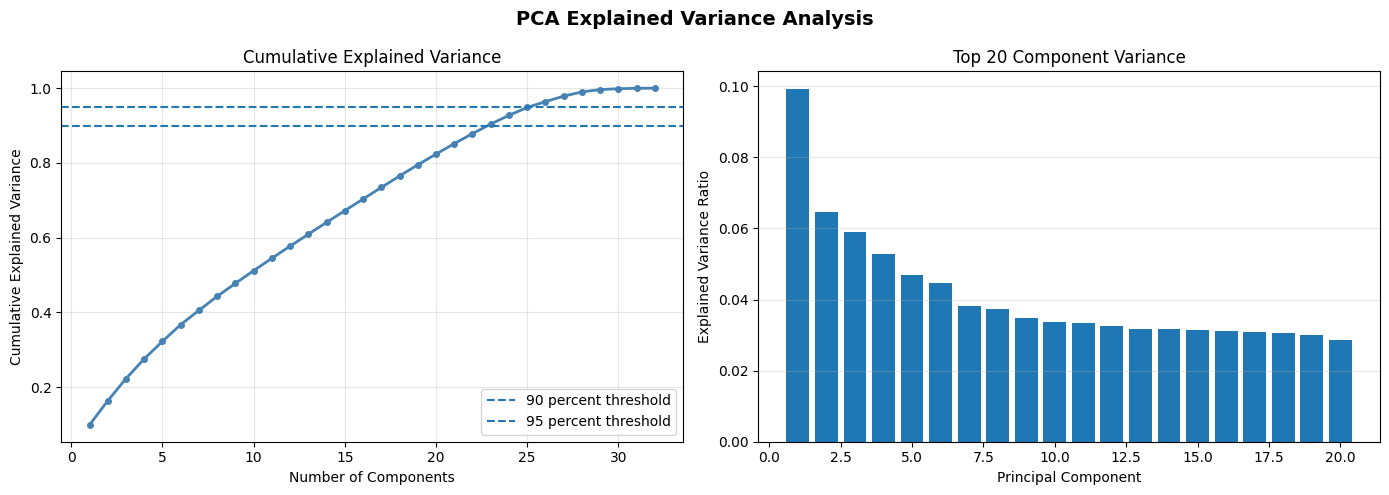

In [23]:
# evaluate pca with different number of components using cross validation
pca_k_values = [5, 10, 15, 20, 25, 30]
pca_results = {}

for n_comp in pca_k_values:
    n_actual = min(n_comp, n_total_features)

    # pipeline with scaling, pca transformation, and classification
    pipe_pca = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_actual, random_state=42)),
        ("clf", LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))
    ])

    # evaluate with cross validation
    cv_scores = cross_val_score(
        pipe_pca,
        X_fs,
        y_fs,
        cv=CV,
        scoring="f1_weighted",
        n_jobs=-1
    )

    mean_f1 = cv_scores.mean()
    pca_results[n_actual] = mean_f1

    print(f"[PCA] n_components={n_actual} F1={mean_f1:.4f}")


# scale data before fitting full pca for variance analysis
X_fs_scaled = StandardScaler().fit_transform(X_fs)

# fit full pca to compute explained variance
pca_full = PCA(random_state=42).fit(X_fs_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)


# plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA Explained Variance Analysis", fontsize=14, fontweight="bold")

# plot cumulative explained variance
axes[0].plot(
    range(1, len(cumvar) + 1),
    cumvar,
    marker="o",
    markersize=4,
    color="steelblue",
    linewidth=2
)
axes[0].axhline(0.90, linestyle="--", label="90 percent threshold")
axes[0].axhline(0.95, linestyle="--", label="95 percent threshold")
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].set_title("Cumulative Explained Variance")
axes[0].legend()
axes[0].grid(alpha=0.3)

# plot top component variance
top_n = min(20, len(pca_full.explained_variance_ratio_))
axes[1].bar(
    range(1, top_n + 1),
    pca_full.explained_variance_ratio_[:top_n]
)
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Explained Variance Ratio")
axes[1].set_title(f"Top {top_n} Component Variance")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

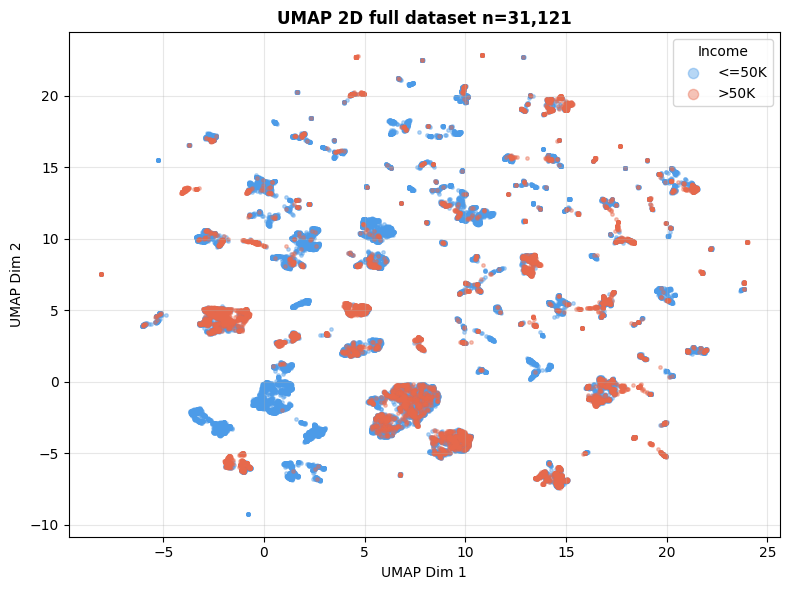

In [33]:
# apply umap for dimensionality reduction without using labels
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap_2d = reducer.fit_transform(X_fs_scaled)

# visualize umap projection
plt.figure(figsize=(8, 6))

palette = {0: "#4C9BE8", 1: "#E8694C"}
labels = {0: "<=50K", 1: ">50K"}

# plot umap projection
y_fs_array = y_fs.values if hasattr(y_fs, "values") else y_fs

for cls in [0, 1]:
    mask = y_fs_array == cls
    plt.scatter(
        X_umap_2d[mask, 0],
        X_umap_2d[mask, 1],
        c=palette[cls],
        label=labels[cls],
        alpha=0.4,
        s=6,
        rasterized=True
    )

plt.title(
    f"UMAP 2D full dataset n={X_fs.shape[0]:,}",
    fontsize=12,
    fontweight="bold"
)
plt.xlabel("UMAP Dim 1")
plt.ylabel("UMAP Dim 2")
plt.legend(title="Income", markerscale=3)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **Nhận xét:**

Biểu đồ UMAP với 31,121 mẫu dữ liệu cho thấy cấu trúc cụm (cluster) phức tạp và đa dạng trong không gian đặc trưng sau khi đã được giảm chiều:

1. **Phân tách lớp (Class Separation):** 
   - Có sự phân tách tương đối rõ ràng giữa hai nhóm thu nhập <=50K (màu xanh) và >50K (màu cam) tại một số vùng cục bộ
   - Các cụm lớn tập trung chủ yếu ở vùng trung tâm (UMAP Dim 1: 0-15, Dim 2: -5 đến 15)
   - Một số cụm thể hiện tính thuần khiết cao về lớp, ví dụ: cụm màu cam đậm ở vùng (Dim 1: 5-10, Dim 2: -5 đến 0) chủ yếu là samples có thu nhập >50K

2. **Mức độ chồng chéo (Overlap):**
   - Vẫn tồn tại sự chồng chéo đáng kể giữa hai lớp tại nhiều vùng, đặc biệt ở các cụm nhỏ phân tán
   - Điều này phản ánh tính chất phức tạp của bài toán phân loại, nơi các đặc trưng kinh tế-xã hội không hoàn toàn tuyến tính separable

3. **Cấu trúc cụm (Cluster Structure):**
   - Dữ liệu hình thành khoảng 20-30 cụm riêng biệt với kích thước và mật độ khác nhau
   - Các cụm có xu hướng phân tán theo cả hai chiều UMAP, cho thấy sự đa dạng trong hồ sơ nhân khẩu học
   - Một số cụm lớn, đậm đặc (ví dụ: vùng Dim 1: 0-5, Dim 2: -5 đến 5) chứa đa số samples thuộc lớp <=50K

4. **Ý nghĩa đối với mô hình học máy:**
   - Cấu trúc cụm phi tuyến này giải thích tại sao các mô hình như Random Forest hay Gradient Boosting (có khả năng học decision boundaries phức tạp) thường hoạt động tốt hơn so với các mô hình tuyến tính
   - Sự tồn tại của các cụm thuần khiết cho thấy có những nhóm đặc trưng con (feature subsets) có thể phân loại chính xác cao
   - Vùng overlap gợi ý cần feature engineering hoặc selection để cải thiện khả năng phân tách

5. **Insights về dữ liệu:**
   - Các samples cùng lớp có xu hướng tập trung gần nhau trong không gian embedding, cho thấy UMAP đã bảo toàn tốt cấu trúc cục bộ của dữ liệu gốc
   - Sự phân tán rộng của cả hai lớp cho thấy dataset có độ đa dạng cao về đặc trưng nhân khẩu học và kinh tế

### **7.5 Comparative Analysis & Final Strategy**

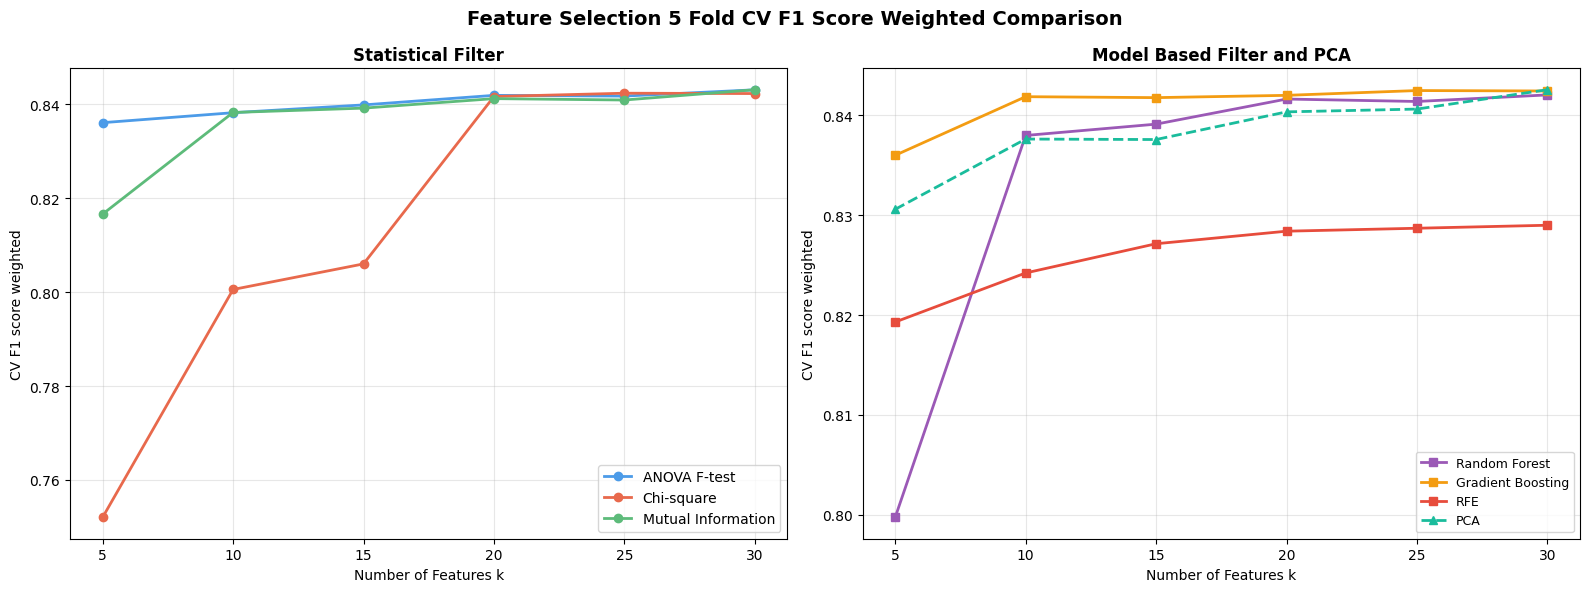

SUMMARY TABLE BEST F1 PER METHOD
Method                      Best k    Best F1
----------------------------------------------
ANOVA F-test                    30     0.8431
Chi-square                      25     0.8424
Mutual Information              30     0.8431
Random Forest                   30     0.8421
Gradient Boosting               25     0.8425
RFE                             30     0.8290
PCA                             30     0.8426
Best method: Mutual Information k=30 F1=0.8431


In [35]:
# plot comparison of feature selection methods
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Feature Selection 5 Fold CV F1 Score Weighted Comparison",
    fontsize=14,
    fontweight="bold"
)

# plot statistical filter results
stat_colors = {
    "ANOVA F-test": "#4C9BE8",
    "Chi-square": "#E8694C",
    "Mutual Information": "#5DBB7A",
}

for method_name, scores_dict in stat_results.items():
    ks_ = sorted(scores_dict.keys())
    f1s_ = [scores_dict[k] for k in ks_]

    axes[0].plot(
        ks_,
        f1s_,
        marker="o",
        linewidth=2,
        label=method_name,
        color=stat_colors[method_name]
    )

axes[0].set_title("Statistical Filter", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Features k")
axes[0].set_ylabel("CV F1 score weighted")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(sorted(set(k_values)))


# plot model based filter results
model_colors = {
    "Random Forest": "#9B59B6",
    "Gradient Boosting": "#F39C12",
    "RFE": "#E74C3C",
}

for model_name, scores_dict in model_results.items():
    ks_ = sorted(scores_dict.keys())
    f1s_ = [scores_dict[k] for k in ks_]

    axes[1].plot(
        ks_,
        f1s_,
        marker="s",
        linewidth=2,
        label=model_name,
        color=model_colors[model_name]
    )

# plot pca results
pca_ks_ = sorted(pca_results.keys())
pca_f1s_ = [pca_results[k] for k in pca_ks_]

axes[1].plot(
    pca_ks_,
    pca_f1s_,
    marker="^",
    linewidth=2,
    linestyle="--",
    label="PCA",
    color="#1ABC9C"
)

axes[1].set_title("Model Based Filter and PCA", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Features k")
axes[1].set_ylabel("CV F1 score weighted")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(sorted(set(k_values)))

plt.tight_layout()
plt.show()


# print summary table of best results
print("SUMMARY TABLE BEST F1 PER METHOD")
print(f"{'Method':<25} {'Best k':>8} {'Best F1':>10}")
print("-" * 46)

all_methods_summary = {}

# summarize statistical methods
for m, d in stat_results.items():
    best_k = max(d, key=d.get)
    best_f1 = d[best_k]
    all_methods_summary[m] = (best_k, best_f1)

    print(f"{m:<25} {best_k:>8} {best_f1:>10.4f}")

# summarize model based methods
for m, d in model_results.items():
    best_k = max(d, key=d.get)
    best_f1 = d[best_k]
    all_methods_summary[m] = (best_k, best_f1)

    print(f"{m:<25} {best_k:>8} {best_f1:>10.4f}")

# summarize pca
best_pca_k = max(pca_results, key=pca_results.get)
best_pca_f1 = pca_results[best_pca_k]
all_methods_summary["PCA"] = (best_pca_k, best_pca_f1)

print(f"{'PCA':<25} {best_pca_k:>8} {best_pca_f1:>10.4f}")

# find best overall method
best_method = max(all_methods_summary, key=lambda m: all_methods_summary[m][1])
best_k_overall, best_f1_overall = all_methods_summary[best_method]

print(f"Best method: {best_method} k={best_k_overall} F1={best_f1_overall:.4f}")

Dựa trên kết quả chạy thử nghiệm 5-fold CV F1-score (weighted) từ các phương pháp tiếp cận khác nhau, nhóm đã tổng hợp kết quả vào bảng dưới đây nhằm cung cấp một cái nhìn toàn cảnh. Đặc biệt, nhóm quyết định loại bỏ mốc $k=32$ (toàn bộ dữ liệu) để bài toán thực sự phản ánh bản chất của quá trình **Feature Selection** (Lựa chọn đặc trưng) thay vì chỉ là bước đánh giá (Evaluation) thông thường.

| Phương pháp | k = 5 | k = 10 | k = 15 | k = 20 | k = 25 | k = 30 | Best F1 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **ANOVA F-test** | **0.8361** | 0.8382 | 0.8399 | 0.8419 | 0.8417 | **0.8431** | 0.8431 (k=30) |
| **Chi-square** | 0.7520 | 0.8006 | 0.8060 | 0.8416 | 0.8424 | 0.8423 | 0.8424 (k=25) |
| **Mutual Information** | 0.7727 | 0.8378 | 0.8396 | 0.8411 | 0.8412 | 0.8422 | 0.8422 (k=30) |
| **Random Forest** | 0.7997 | 0.8380 | 0.8391 | 0.8416 | 0.8414 | 0.8421 | 0.8421 (k=30) |
| **Gradient Boosting** | **0.8360** | **0.8419** | 0.8418 | 0.8420 | 0.8425 | 0.8424 | 0.8425 (k=25) |
| **RFE** (Logistic Reg) | 0.8193 | 0.8242 | 0.8271 | 0.8284 | 0.8287 | 0.8290 | 0.8290 (k=30) |
| **PCA** | 0.8306 | 0.8376 | 0.8376 | 0.8404 | 0.8406 | 0.8426 | 0.8426 (k=30) |

---

##### **Statistical Filter (Lọc Thống Kê)**
Thông qua 3 phương pháp lọc thống kê, nhóm em rút ra các quan sát quan trọng về chất lượng từng đặc trưng độc lập:

* **Sức mạnh vượt trội của ANOVA F-test ở số chiều thấp:** Khi giới hạn cực đoan số lượng đặc trưng (k=5), ANOVA F-test cho thấy hiệu suất xuất sắc với F1 đạt **0.8361**. Trong khi đó, Chi-square (0.7520) và Mutual Information (0.7727) tỏ ra khá chật vật. Điều này ngụ ý rằng top 5 đặc trưng do ANOVA chọn có độ tương quan tuyến tính cực kỳ mạnh mẽ với biến mục tiêu, rất phù hợp với thuật toán base model là Logistic Regression.
* **Sự hội tụ của các phương pháp (Saturation Point):** Hiệu năng của mô hình tăng dần khi thêm đặc trưng nhưng nhanh chóng bão hòa. Khi số lượng đặc trưng $k \ge 20$, cả ba phương pháp đều hội tụ về cùng một mức hiệu năng (~0.841 - 0.842). Sự chênh lệch giữa việc dùng 20 đặc trưng và dùng 30 đặc trưng là không đáng kể. Điều này cho thấy ở quy mô k=20, cả 3 bộ lọc đều đã "gom" đủ những đặc trưng mang tính quyết định nhất.

##### **Model-Based Filter (Lọc Dựa Trên Mô Hình)**
Tầng đánh giá này khai thác sự tương tác giữa các biến, mang lại những góc nhìn kỹ thuật sâu sắc hơn:

* **Sự nhạy bén của Gradient Boosting:** Ở mức giới hạn (k=5), tập đặc trưng do Gradient Boosting (GB) lựa chọn cho hiệu suất vượt trội (F1 = **0.8360**) so với Random Forest (F1 = **0.7997**). Cơ chế xây dựng cây tuần tự (boosting) giúp GB nhận diện và gán trọng số cho các đặc trưng cốt lõi tốt hơn hẳn cơ chế lấy mẫu ngẫu nhiên (bagging) của Random Forest khi bị giới hạn số lượng gắt gao. Đặc biệt tại k=10, GB bứt phá mạnh mẽ đạt F1 **0.8419**.
* **Sự hụt hơi của RFE (Recursive Feature Elimination):** Ngay cả ở mức k=30, F1 của RFE chỉ lẹt đẹt ở mức 0.8290. Theo nhóm em phân tích, nguyên nhân đến từ việc RFE sử dụng Logistic Regression làm base estimator để tính trọng số đệ quy. Thuật toán phân tuyến tính này có thể đã loại bỏ nhầm các đặc trưng mang tính tương tác phi tuyến (non-linear interactions) ở những bước đầu tiên, dẫn đến một tập con không thực sự tối ưu.

##### **Dimensionality Reduction (Giảm chiều với PCA)**
* **Sự đánh đổi của PCA (The Explainability Trade-off):** PCA thể hiện khả năng nén thông tin rất tốt và ổn định (khởi đầu ở 0.8306 tại k=5 và đạt cực đại 0.8426 tại k=30). Tuy nhiên, vì PCA tạo ra các không gian trục mới (Principal Components) bằng cách kết hợp tuyến tính tất cả các đặc trưng gốc, mô hình sẽ **mất hoàn toàn khả năng diễn giải (Explainability)**. Nhóm không thể giải thích cho người dùng cuối (end-users) rằng "Thành phần chính số 1" đại diện cho cái gì trong thực tế.

---

### **ĐÁNH GIÁ TỔNG QUAN & ĐỀ XUẤT CUỐI CÙNG**

Dựa trên sự cân bằng giữa **Hiệu năng dự đoán (Predictive Power)**, **Chi phí tính toán (Computational Complexity)** và **Khả năng diễn giải (Explainability)**, nhóm đi đến kết luận thực chiến sau:

1. **Về mặt kỹ thuật thuần túy:** Thuật toán **ANOVA F-test** đạt điểm F1 cao nhất toàn vòng khảo sát (0.8431 tại k=30). Tuy nhiên, mức tăng từ 0.8419 (tại k=10 của Gradient Boosting) lên 0.8431 mang lại biên lợi nhuận quá nhỏ (~0.1%) so với việc phải nhồi nhét thêm 20 features vào hệ thống.
2. **Lựa chọn (Pragmatic Engineering):** Gradient Boosting đóng vai trò xuất sắc nhất. Đề xuất tối ưu nhất của nhóm là **giữ lại Top 10 đặc trưng do Gradient Boosting lựa chọn**. Quyết định này mang lại các lợi ích to lớn:
    * Giảm thiểu hơn **68%** chiều dữ liệu rườm rà (từ 32 xuống 10), giúp tối ưu tốc độ huấn luyện và độ trễ (latency) khi dự đoán thực tế.
    * Giảm nguy cơ Data Drift (trôi dạt dữ liệu) trong tương lai do phải bảo trì quá nhiều cột thông tin không thiết yếu.
    * Vẫn giữ trọn vẹn hơn **99.9%** sức mạnh dự đoán nguyên bản của mô hình, đồng thời duy trì được tính diễn giải logic của từng cột dữ liệu.

---

## **8. Class Imbalance Detection & Treatment**

**Mục tiêu:** Phát hiện tình trạng mất cân bằng lớp trong tập dữ liệu, sau đó áp dụng và so sánh 3 chiến lược tái cân bằng: SMOTE (Over-sampling), ADASYN (Adaptive Over-sampling) và Random Under-sampling. Mỗi chiến lược được đánh giá trên tập test *chưa tái cân bằng* bằng các chỉ số Precision, Recall, F1-macro và AUC-ROC.

### **8.1 Theoretical Foundation & Mathematical Formulas**

#### 1. Mất cân bằng lớp (Class Imbalance)

* **Định nghĩa:** Xảy ra khi một lớp (minority class) chiếm tỷ lệ nhỏ hơn đáng kể so với lớp còn lại (majority class). Tỷ lệ mất cân bằng (Imbalance Ratio) được tính là $IR = \frac{N_{majority}}{N_{minority}}$.
* **Hậu quả:** Mô hình học máy có xu hướng thiên lệch (bias) về phía lớp đa số, dẫn đến Accuracy giả tạo cao nhưng Recall trên lớp thiểu số cực kỳ thấp — một vấn đề nghiêm trọng trong bài toán phân loại thu nhập.

#### 2. SMOTE — Synthetic Minority Over-sampling Technique

* **Lý thuyết:** Thay vì nhân bản thuần túy (Random Over-sampling), SMOTE tạo ra các mẫu tổng hợp *mới* bằng cách nội suy tuyến tính giữa một điểm thiểu số và $k$ hàng xóm gần nhất của nó trong không gian đặc trưng.
* **Công thức sinh mẫu:**
  $$x_{new} = x_i + \lambda \cdot (x_{zi} - x_i), \quad \lambda \in [0, 1]$$
  *(Trong đó $x_i$ là mẫu thiểu số gốc, $x_{zi}$ là một hàng xóm ngẫu nhiên trong $k$-NN, $\lambda$ là hệ số nội suy ngẫu nhiên).*
* **Ưu điểm:** Tạo ra vùng quyết định (decision boundary) phong phú hơn, không bị overfitting trên các bản sao trùng lặp.

#### 3. ADASYN — Adaptive Synthetic Sampling

* **Lý thuyết:** Mở rộng của SMOTE, ADASYN tập trung tạo mẫu tổng hợp *nhiều hơn* ở vùng ranh giới quyết định khó phân loại — nơi mà mẫu thiểu số bị bao vây bởi nhiều mẫu đa số nhất.
* **Cơ chế thích ứng:** Tính trọng số $r_i$ cho từng mẫu thiểu số $x_i$ dựa trên tỷ lệ hàng xóm đa số trong $k$-NN:
  $$r_i = \frac{\Delta_i}{k}, \quad \hat{r}_i = \frac{r_i}{\sum_{i=1}^{m_s} r_i}$$
  *(Trong đó $\Delta_i$ là số hàng xóm thuộc lớp đa số, $m_s$ là tổng số mẫu thiểu số).* Số mẫu cần sinh cho mỗi điểm: $g_i = \hat{r}_i \cdot G$.
* **Ưu điểm:** Giảm độ lệch (bias) của boundary vùng quyết định, tập trung tài nguyên vào vùng khó nhất.

#### 4. Random Under-sampling

* **Lý thuyết:** Giảm ngẫu nhiên số lượng mẫu từ lớp đa số cho đến khi hai lớp cân bằng. Phương pháp đơn giản nhất về mặt tính toán nhưng có rủi ro mất đi thông tin hữu ích (information loss) từ lớp đa số.
* **Chiến lược:** Gọi $N_{min}$ là kích thước lớp thiểu số, chọn ngẫu nhiên $N_{min}$ mẫu từ lớp đa số (không hoàn lại) để tạo tập train cân bằng.

#### 5. Tại sao KHÔNG áp dụng resampling trước khi chia train/test?

Đây là một **lỗi phương pháp luận nghiêm trọng** (Data Leakage) cần tuyệt đối tránh:

* **Data Leakage:** Nếu SMOTE/ADASYN được áp dụng *trước* khi chia, các mẫu tổng hợp ($x_{new}$) được nội suy từ toàn bộ dữ liệu — bao gồm cả phần sau này sẽ trở thành tập test. Điều này có nghĩa là tập train "nhìn thấy" thông tin thống kê từ tập test, vi phạm nguyên tắc độc lập.
* **Đánh giá lạc quan giả tạo:** Mô hình đánh giá trên tập test có chứa các mẫu tổng hợp được tính từ chính phân phối test, dẫn đến các chỉ số AUC-ROC và F1 bị thổi phồng (inflated), không phản ánh hiệu năng thực tế trên dữ liệu triển khai (production data).
* **Quy trình đúng:** Chỉ áp dụng resampling **bên trong tập train**, sau khi đã chia tập test ra độc lập. Tập test luôn giữ nguyên phân phối tự nhiên (imbalanced) để phản ánh điều kiện thực tế.


### **8.2 Class Distribution Analysis**

Trước tiên, nhóm kiểm tra tình trạng mất cân bằng trong tập dữ liệu sau khi đã tiền xử lý. Sử dụng vector nhãn `y_fs` đã được chuẩn bị ở Bước 7.

CLASS DISTRIBUTION ANALYSIS
Class           Count    Ratio (%)
-----------------------------------
<=50K (0)      24,075       77.36%
>50K (1)        7,046       22.64%
Imbalance Ratio IR : 3.42:1
Minority class size : 7,046
Majority class size : 24,075
Class imbalance detected IR >= 3


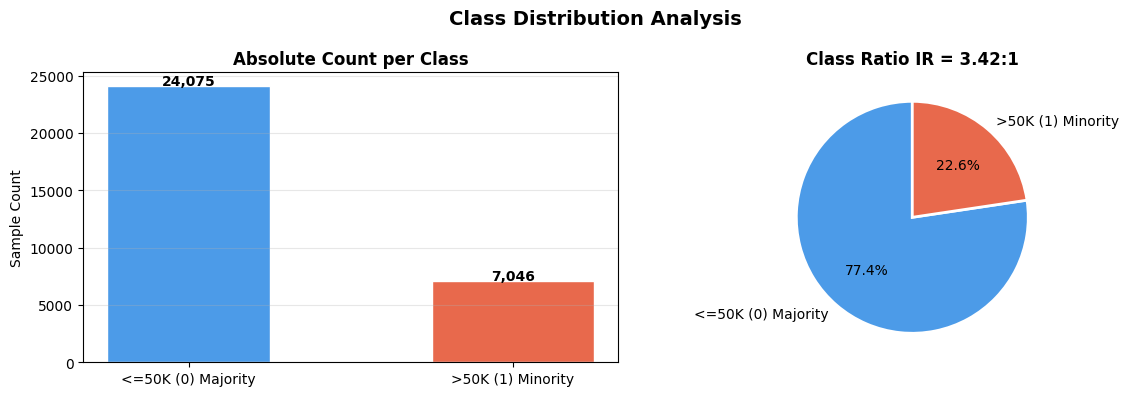

In [29]:
# analyze class distribution and imbalance ratio
class_counts = Counter(y_fs)
n_total_samples = len(y_fs)

print("CLASS DISTRIBUTION ANALYSIS")
print(f"{'Class':<12} {'Count':>8} {'Ratio (%)':>12}")
print("-" * 35)

for cls, cnt in sorted(class_counts.items()):
    label = "<=50K (0)" if cls == 0 else ">50K (1)"
    print(f"{label:<12} {cnt:>8,} {cnt / n_total_samples * 100:>11.2f}%")

# compute imbalance ratio
n_majority = class_counts[0]
n_minority = class_counts[1]
ir = n_majority / n_minority

print(f"Imbalance Ratio IR : {ir:.2f}:1")
print(f"Minority class size : {n_minority:,}")
print(f"Majority class size : {n_majority:,}")

# check imbalance condition
if ir >= 3:
    print("Class imbalance detected IR >= 3")
else:
    print("Dataset is relatively balanced IR < 3")


# plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Distribution Analysis", fontsize=14, fontweight="bold")

labels_ = ["<=50K (0) Majority", ">50K (1) Minority"]
counts_ = [class_counts[0], class_counts[1]]
colors_ = ["#4C9BE8", "#E8694C"]

# bar chart of class counts
axes[0].bar(labels_, counts_, color=colors_, edgecolor="white", width=0.5)
axes[0].set_title("Absolute Count per Class", fontweight="bold")
axes[0].set_ylabel("Sample Count")

for i, v in enumerate(counts_):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontweight="bold")

axes[0].grid(axis="y", alpha=0.3)

# pie chart of class ratio
axes[1].pie(
    counts_,
    labels=labels_,
    colors=colors_,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

axes[1].set_title(f"Class Ratio IR = {ir:.2f}:1", fontweight="bold")

plt.tight_layout()
plt.show()

### **8.3 Resampling Strategies Implementation**

Nhóm tiến hành chia tập dữ liệu **trước**, sau đó áp dụng từng chiến lược tái cân bằng **chỉ trên tập train**. Tập test luôn giữ nguyên phân phối tự nhiên (imbalanced) để đánh giá hiệu năng trên điều kiện thực tế. Đây là điểm mấu chốt ngăn chặn Data Leakage.

Mô hình đánh giá: **Logistic Regression** (nhất quán với `BASE_MODEL` ở Bước 7).

In [26]:
# split dataset into train and test with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_fs,
    y_fs,
    test_size=0.2,
    random_state=42,
    stratify=y_fs
)

# print split summary
print("TRAIN TEST SPLIT")
print(f"Train size : {X_train.shape[0]:,} | Class dist: {Counter(y_train)}")
print(f"Test size  : {X_test.shape[0]:,} | Class dist: {Counter(y_test)}")
print("Test set is not resampled and keeps original distribution")


# define resampling strategies
resampling_strategies = {
    "Original No Resampling": None,
    "SMOTE": SMOTE(random_state=42, k_neighbors=5),
    "ADASYN": ADASYN(random_state=42),
    "Random Under-sampling": RandomUnderSampler(random_state=42),
}

# store evaluation results
imbalance_results = {}

print("RESAMPLING AND TRAINING SUMMARY")
print(f"{'Strategy':<30} {'Train (0)':>10} {'Train (1)':>10}")
print("-" * 52)

for strategy_name, resampler in resampling_strategies.items():

    # apply resampling only on training set
    if resampler is None:
        X_res, y_res = X_train, y_train
    else:
        X_res, y_res = resampler.fit_resample(X_train, y_train)

    # print class distribution after resampling
    dist = Counter(y_res)
    print(f"{strategy_name:<30} {dist[0]:>10,} {dist[1]:>10,}")

    # train logistic regression model
    model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    model.fit(X_res, y_res)

    # evaluate on original test set
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # store evaluation metrics
    imbalance_results[strategy_name] = {
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_pred_prob),
        "_y_pred": y_pred,
        "_y_prob": y_pred_prob,
    }

TRAIN TEST SPLIT
Train size : 24,896 | Class dist: Counter({0: 19259, 1: 5637})
Test size  : 6,225 | Class dist: Counter({0: 4816, 1: 1409})
Test set is not resampled and keeps original distribution
RESAMPLING AND TRAINING SUMMARY
Strategy                        Train (0)  Train (1)
----------------------------------------------------
Original No Resampling             19,259      5,637
SMOTE                              19,259     19,259
ADASYN                             19,259     19,250
Random Under-sampling               5,637      5,637


### **8.4 Evaluation Results**

So sánh Precision, Recall, F1-macro và AUC-ROC trên tập test *chưa tái cân bằng* giữa 4 chiến lược.

EVALUATION ON UNBALANCED TEST SET


,Precision,Recall,F1-macro,AUC-ROC
Original No Resampling,0.7115,0.5635,0.7673,0.9024
SMOTE,0.5398,0.8566,0.7612,0.9014
ADASYN,0.4881,0.8992,0.7293,0.8955
Random Under-sampling,0.5324,0.8623,0.7572,0.9024


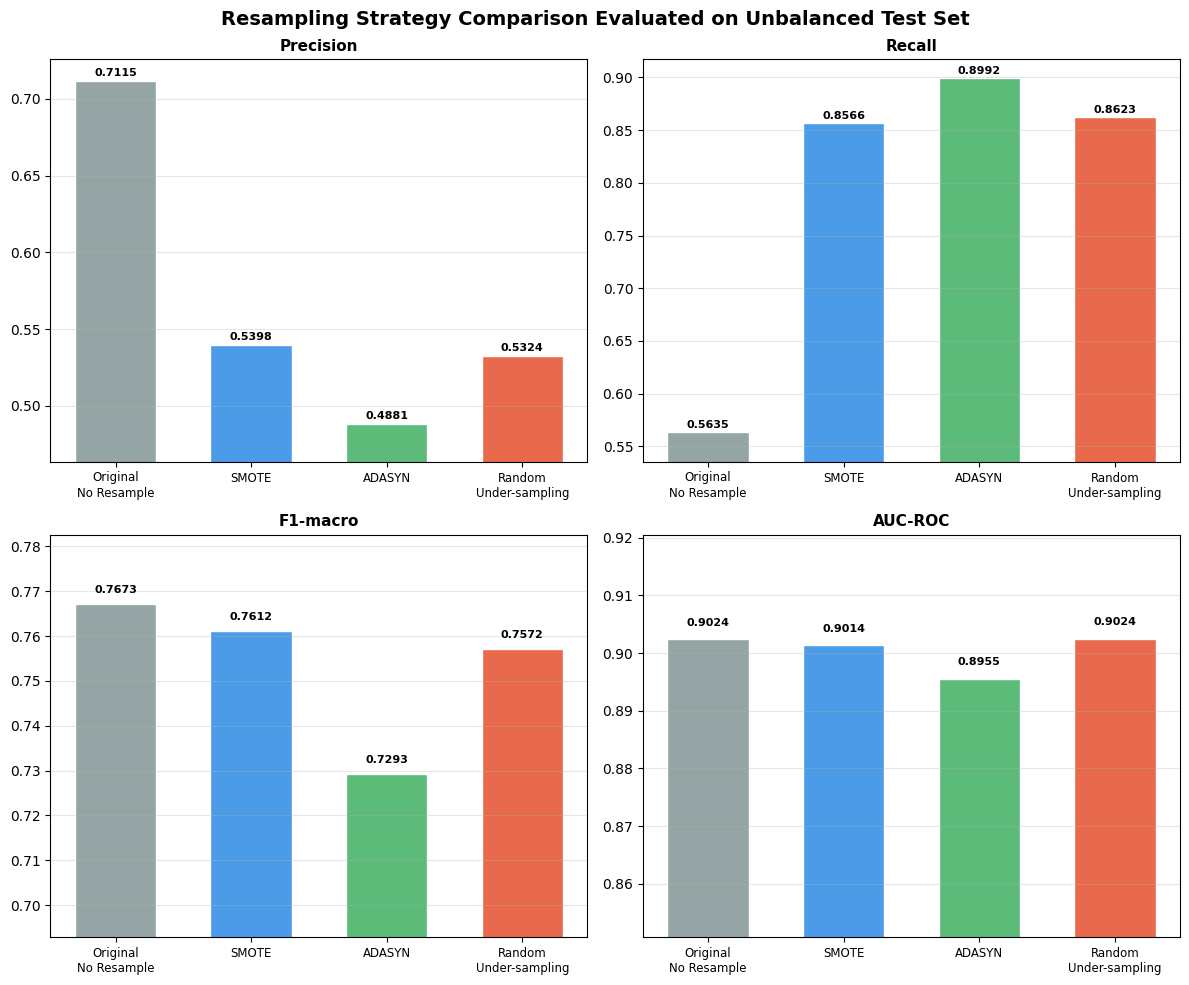

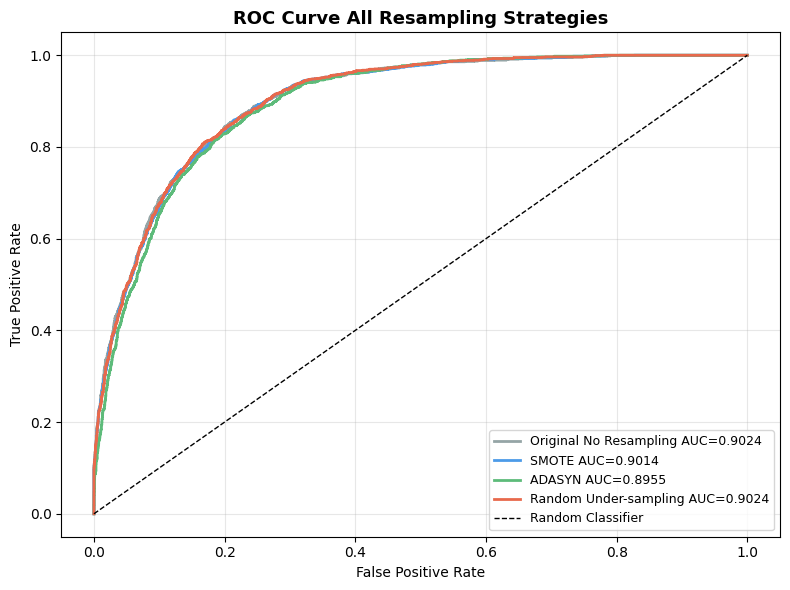

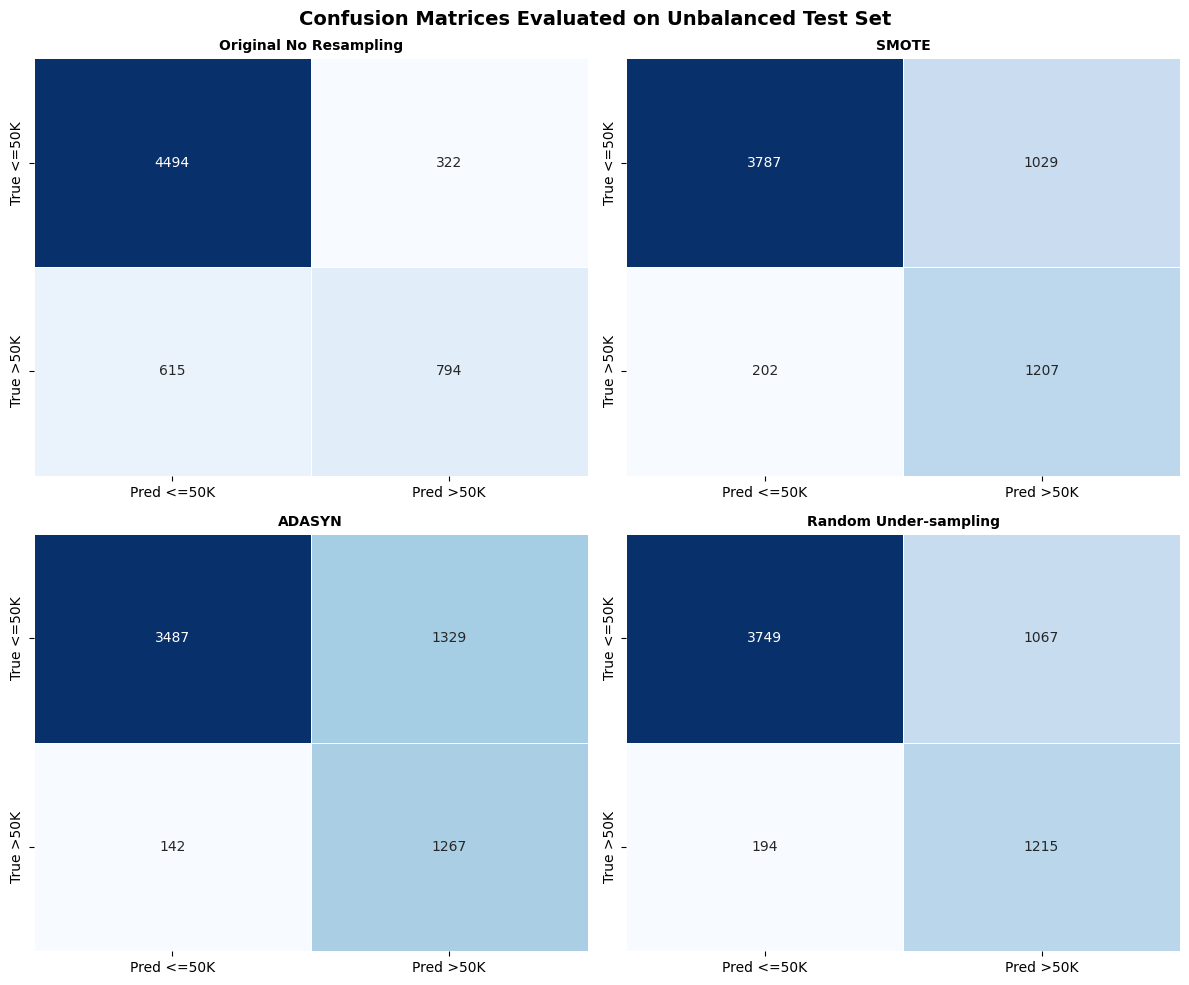

In [28]:
# build summary table for evaluation metrics
metric_keys = ["Precision", "Recall", "F1-macro", "AUC-ROC"]

df_imbalance = pd.DataFrame(
    {
        strategy: {k: v for k, v in metrics.items() if not k.startswith("_")}
        for strategy, metrics in imbalance_results.items()
    }
).T[metric_keys]

# display styled table
print("EVALUATION ON UNBALANCED TEST SET")
display(
    df_imbalance.style
    .format("{:.4f}")
    .highlight_max(axis=0, color="#267F82")
    .highlight_min(axis=0, color="#923232")
)


# plot bar charts for each metric
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(
    "Resampling Strategy Comparison Evaluated on Unbalanced Test Set",
    fontsize=14,
    fontweight="bold"
)

strategy_colors = {
    "Original No Resampling": "#95A5A6",
    "SMOTE": "#4C9BE8",
    "ADASYN": "#5DBB7A",
    "Random Under-sampling": "#E8694C",
}

for ax, metric in zip(axes.flatten(), metric_keys):
    values = [imbalance_results[s][metric] for s in imbalance_results]
    strategies = list(imbalance_results.keys())
    colors_ = [strategy_colors[s] for s in strategies]

    # bar chart for metric comparison
    bars = ax.bar(
        range(len(strategies)),
        values,
        color=colors_,
        edgecolor="white",
        width=0.6
    )

    ax.set_title(metric, fontweight="bold", fontsize=11)
    ax.set_xticks(range(len(strategies)))
    ax.set_xticklabels(
        [
            s.replace(" No Resampling", "\nNo Resample").replace("Random ", "Random\n")
            for s in strategies
        ],
        fontsize=8.5
    )

    ax.set_ylim(min(values) * 0.95, max(values) * 1.02)
    ax.grid(axis="y", alpha=0.3)

    # annotate bar values
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{val:.4f}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()


# plot roc curves for all strategies
plt.figure(figsize=(8, 6))
roc_colors = list(strategy_colors.values())

for (strategy_name, metrics), color in zip(imbalance_results.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, metrics["_y_prob"])
    auc_val = metrics["AUC-ROC"]

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        color=color,
        label=f"{strategy_name} AUC={auc_val:.4f}"
    )

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve All Resampling Strategies", fontsize=13, fontweight="bold")
plt.legend(fontsize=9, loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# plot confusion matrices for all strategies
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(
    "Confusion Matrices Evaluated on Unbalanced Test Set",
    fontsize=14,
    fontweight="bold"
)

for ax, (strategy_name, metrics) in zip(axes.flatten(), imbalance_results.items()):
    cm = confusion_matrix(y_test, metrics["_y_pred"])

    # heatmap for confusion matrix
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred <=50K", "Pred >50K"],
        yticklabels=["True <=50K", "True >50K"],
        ax=ax,
        cbar=False,
        linewidths=0.5
    )

    ax.set_title(strategy_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Evaluation and Analysis of Resampling Strategies

Dựa trên bảng tổng hợp kết quả và các biểu đồ trực quan (Bar Chart, ROC Curve, Confusion Matrix) được đánh giá độc lập trên tập Test chưa qua xử lý, nhóm rút ra những nhận định chi tiết về tác động của các kỹ thuật tái cân bằng dữ liệu đối với lớp thiểu số (>50K) như sau:

#### 1. Sự đánh đổi (Trade-off) giữa Recall và Precision
* **Mô hình gốc (Original - No Resampling):** * Do dữ liệu huấn luyện bị mất cân bằng (nghiêng về lớp `≤50K`), mô hình gốc có xu hướng "thiên vị" lớp đa số. 
    * Kết quả thể hiện rõ: Mô hình dự đoán rất chuẩn xác những người có thu nhập `≤50K` (False Positive thấp), giúp **Precision (>50K) đạt mức cao nhất (0.7115)**. Tuy nhiên, mô hình lại bỏ sót một lượng lớn các quan sát thuộc lớp `>50K`, dẫn đến **Recall (>50K) ở mức rất thấp, chỉ đạt 0.5635**.
* **Tác động của Resampling (SMOTE, ADASYN, Under-sampling):**
    * Các phương pháp này đã hoàn thành xuất sắc mục tiêu ép mô hình "chú ý" nhiều hơn đến lớp thiểu số. Số lượng dự đoán đúng nhãn `>50K` (True Positive) tăng lên mạnh mẽ, kéo theo **chỉ số Recall (>50K) tăng vọt lên khoảng 0.85 - 0.89**.
    * **Mặt trái:** Sự gia tăng Recall đi kèm với sự sụt giảm nghiêm trọng của Precision (rớt xuống chỉ còn khoảng 0.48 - 0.53). Việc không gian quyết định (decision boundary) của lớp `>50K` được mở rộng đã vô tình lấn lướt sang vùng của lớp `≤50K`, khiến hiện tượng đoán nhầm lớp đa số thành lớp thiểu số diễn ra nhiều hơn (thà bắt nhầm còn hơn bỏ sót).

#### 2. Đánh giá sự đánh mất thông tin trong Random Under-sampling
* Quan sát kết quả của **Random Under-sampling**, nhóm nhận thấy phương pháp này tuy mang lại Recall rất cao (0.8623) nhưng Precision lại bị sụt giảm lớn (chỉ còn 0.5324).
* **Giải thích:** Việc cắt bỏ ngẫu nhiên một lượng lớn dữ liệu lớp đa số để số lượng bằng với lớp thiểu số đã gây ra **hiện tượng mất mát thông tin (information loss)**. Mô hình không được học đủ các khuôn mẫu (patterns) đa dạng của nhóm người có thu nhập thấp, dẫn đến năng lực phân biệt bị suy giảm, làm tăng số lượng dự đoán nhầm (False Positive).

#### 3. Điểm cân bằng F1-Macro và Khả năng phân tách (AUC-ROC)
* **F1-Macro:** Vì F1-Macro đánh giá mức độ hài hòa của cả 2 lớp, nên **Mô hình gốc (Original)** vẫn chiếm ưu thế cao nhất (0.7673) nhờ khả năng nhận diện cực tốt lớp đa số. Trong số các kỹ thuật can thiệp, **SMOTE** thể hiện sự tối ưu nhất khi giữ được mức F1-Macro (0.7612) tiệm cận nhất với mô hình gốc, trong khi phương pháp ADASYN lại làm F1-Macro giảm mạnh nhất (xuống còn 0.7293) do sinh ra quá nhiều nhiễu.
* **AUC-ROC:** Diện tích dưới đường cong (AUC) của các phương pháp gần như không có sự chênh lệch đáng kể (đều hội tụ ở mức ~0.90). Điều này minh chứng rằng khả năng xếp hạng (ranking) và phân tách dữ liệu của mô hình trên bài toán này là rất ổn định bất chấp việc thay đổi tỷ lệ dữ liệu huấn luyện.

#### 4. Conclusion & Model Selection (Kết luận và Lựa chọn của Nhóm)
Từ những phân tích trên, nhóm nhận thấy **không có phương pháp nào là hoàn hảo tuyệt đối**, việc chọn chiến lược phải phụ thuộc vào bài toán nghiệp vụ (Business Objective) của bộ dữ liệu Adult Income:
1.  **Nếu bài toán ưu tiên độ chính xác (Ví dụ: Xét duyệt khoản vay lớn):** Không được phép nhận diện nhầm người thu nhập thấp thành cao để tránh nợ xấu $\rightarrow$ Nhóm sẽ chọn **Original (No Resampling)** vì có Precision cao nhất (0.7115).
2.  **Nếu bài toán ưu tiên độ phủ (Ví dụ: Chạy chiến dịch Marketing sản phẩm cao cấp):** Thà gửi nhầm quảng cáo cho người thu nhập thấp còn hơn bỏ sót tệp khách hàng VIP $\rightarrow$ Nhóm đánh giá cao kỹ thuật **SMOTE**. SMOTE mang lại khả năng phát hiện nhóm người giàu rất ấn tượng (Recall = 0.8566), nhưng không phá hủy lượng lớn dữ liệu gốc như Under-sampling và ít nhiễu hơn ADASYN, giúp mô hình giữ được sự cân bằng F1-Macro tốt nhất trong các kỹ thuật xử lý mất cân bằng.